# <a id='toc1_'></a>[Introduction: Continued EDA](#toc0_)

In this notebook, I will continue exploring the data, conduct feature engineering, and begin exploring baseline models.

Additional EDA: 
- Explore `market_segment`'s to see if there are any segments that stick out
- Explore `customer_type`'s because having the domain knowledge with working with Group and Contract forecasts, they are very different and difficult to predict.
- Explore how demand and cancellations vary by `customer_type` and `market_segments` 
- Explore the booking windows of the dataset (`lead_time`)

Feature Engineering:
- Combining the two transient `customer_type`'s and dropping both Group and Contract allows the dataset to be more simple and provide a clearer prediction of just transient customers.
- I created a length of stay feature engineering column with the anticipation that this would be helpful in determining cancellations and demand in the future
- The `reservation_status` column was removed from the dataset as this was highly correlated to our target variable since this feature included if the reservation was canceled or not.
- One hot encode categorical columns into numberic values so that they would be ready for modeling

Modeling: (See summary tables below)
- Run baseline logistic regression and random forest models
- Explore Hyperparameter tuning for models that are under performing 
    - Manual hyperparameter optimization
    - Grid search 

Model Evaluation:
- Evaluate Confusion Matrices to identify True Positives, False Positives, True Negatives, and False Negatives from my models
- Compare Classificaion Summaries to identify f-1 scores, precision, and recall
- Explore ROC and AUC curves for top models
- Evaluate Feature Importance of top models


**Table of contents**<a id='toc0_'></a>    
- [Introduction: Continued EDA](#toc1_)    
  - [Table of Contents](#toc1_1_)    
  - [Set Up](#toc1_2_)    
- [Additional EDA](#toc2_)    
  - [Additional Demand EDA:](#toc2_1_)    
    - [Customer Type Demand](#toc2_1_1_)    
    - [Market Segment Demand](#toc2_1_2_)    
  - [Additional Cancellations EDA](#toc2_2_)    
    - [Total Cancellations](#toc2_2_1_)    
    - [Market Segment Cancellations](#toc2_2_2_)    
    - [Customer Type Cancellations](#toc2_2_3_)    
  - [Booking Window EDA](#toc2_3_)    
- [Feature Engineering](#toc3_)    
  - [Customer Type Feature Engineering](#toc3_1_)    
  - [Length of Stay Feature Engineering](#toc3_2_)    
  - [Remove reservation_status](#toc3_3_)    
  - [One Hot Encoding Feature Engineering:](#toc3_4_)    
- [Model Preparation](#toc4_)    
  - [Train/Test Split](#toc4_1_)    
  - [Extract features from datetime columns from X_train and X_test](#toc4_2_)    
  - [Scaling](#toc4_3_)    
- [Baseline Logistic Regression](#toc5_)    
  - [K-Fold Cross-Validation](#toc5_1_)    
  - [Confusion Matrix for Logistic Regression](#toc5_2_)    
- [Baseline Random Forest Model](#toc6_)    
  - [Grid Search for Random Forest Hyperparameters](#toc6_1_)    
    - [Save and Reload grid search results](#toc6_1_1_)    
  - [Random Forest Model with Grid Searched HyperParameters](#toc6_2_)    
  - [Confusion Matrix for Random Forest](#toc6_3_)    
- [Model Comparison](#toc7_)    
  - [Model Evaluation of log_reg](#toc7_1_)    
  - [Model Evaluation of random_forest3](#toc7_2_)    
- [Feature Importance](#toc8_)    
  - [Random Forest Feature Importance:](#toc8_1_)    
  - [Logistic Regression Feature Importance:](#toc8_2_)    
- [Summary](#toc9_)    
- [Appendix](#toc10_)    
  - [Manually identifying best hyperparameters for Random Forest Model](#toc10_1_)    
- [WorkSpace](#toc11_)    
  - [GridSearch for Logistic Regression](#toc11_1_)    
  - [Logistic Regression with optimized Hyperparameter C and max_iter](#toc11_2_)    
  - [Hyperparameter optimization for C](#toc11_3_)    
  - [PCA with Log_Reg model](#toc11_4_)    
  - [Cancellation Days before arrival Feature engineering](#toc11_5_)    
  - [Identify thresholds to maximize f1 score for random forests](#toc11_6_)    
  - [ToDo: Transform the market segment and customer type features so that I can see a breakdown by date with the date as the index](#toc11_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Set Up](#toc0_)

In [221]:
# Standard imports
import numpy as np
import pandas as pd

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# Modeling
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

#Metrics 
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance

# Balancing
from imblearn.over_sampling import SMOTE


from tempfile import mkdtemp
import joblib

In [136]:
# show all dataframe columns
pd.set_option('display.max_columns', None)
# set matplotlib global settings eg. figsize
plt.rcParams['figure.figsize'] = (8.0, 6.0)

In [137]:
# Import hotel_clean_df
clean_df = pd.read_csv('../data/clean_df')

#Import cxl_by_date
cxl_by_date = pd.read_csv('../data/cxl_by_date')

#Import demand_by_date
demand_by_date = pd.read_csv('../data/demand_by_date')

In [138]:
clean_df.head(5)

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2015-07-01,122


In [139]:
#clean_df.head(5)
#cxl_by_date.head(5)
demand_by_date.head(5)

,arrival_date,Demand
0,2015-07-01,122
1,2015-07-02,93
2,2015-07-03,56
3,2015-07-04,88
4,2015-07-05,53


In [140]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_week_number        119390 non-null  int64  
 4   stays_in_weekend_nights         119390 non-null  int64  
 5   stays_in_week_nights            119390 non-null  int64  
 6   adults                          119390 non-null  int64  
 7   children                        119390 non-null  int64  
 8   babies                          119390 non-null  int64  
 9   meal                            119390 non-null  int64  
 10  market_segment                  119390 non-null  object 
 11  distribution_channel            119390 non-null  object 
 12  is_repeated_gues

In [141]:
#Converting date columns back to datetime
clean_df['arrival_date'] = pd.to_datetime(clean_df['arrival_date'])
clean_df['reservation_status_date'] = pd.to_datetime(clean_df['reservation_status_date'])

# <a id='toc2_'></a>[Additional EDA](#toc0_)

- Compare `market_segment` with `distribution_channel`. Are values the same? Can we drop one?
- Demand 
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Cancellations
    - Total Cancellations
    - by `customer_type`
    - by `market_segment`/`distribution_channel`
- Booking Windows
    - Average `lead_time` of each reservation
- Cancellation Windows
    - How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?
    - Cancellation window by `customer_type`
    - Cancellation window by `market_segment`


In [142]:
# Compare market_segment and distribution_channel
print(clean_df[['market_segment','distribution_channel']].value_counts(),'\n\n')
print(clean_df['market_segment'].value_counts(),'\n\n')
print(clean_df['distribution_channel'].value_counts())

market_segment  distribution_channel
Online TA       TA/TO                   56153
Offline TA/TO   TA/TO                   23946
Groups          TA/TO                   17111
Direct          Direct                  12276
Corporate       Corporate                4788
Groups          Direct                   1472
                Corporate                1228
Complementary   Direct                    576
Corporate       TA/TO                     335
Direct          TA/TO                     237
Aviation        Corporate                 227
Offline TA/TO   Corporate                 212
Corporate       Direct                    172
Online TA       GDS                       147
                Direct                    133
Direct          Corporate                  90
Complementary   Corporate                  89
                TA/TO                      78
Offline TA/TO   GDS                        45
Online TA       Corporate                  43
Offline TA/TO   Direct                     

The values "somewhat" overlap, however the market segment is the segmentation of the the guest type.  Whereas the distribution channel is the form in which the reservation was made.  These are indeed different and I will keep them separate.

## <a id='toc2_1_'></a>[Additional Demand EDA:](#toc0_)
- by Customer Type 
- by Demand by Market Segment

### <a id='toc2_1_1_'></a>[Customer Type Demand](#toc0_)

In [143]:
# Demand by customer_type
clean_df['customer_type'].value_counts(normalize=True) *100

customer_type
Transient          75.059050
Transient-Party    21.043638
Contract            3.414021
Group               0.483290
Name: proportion, dtype: float64

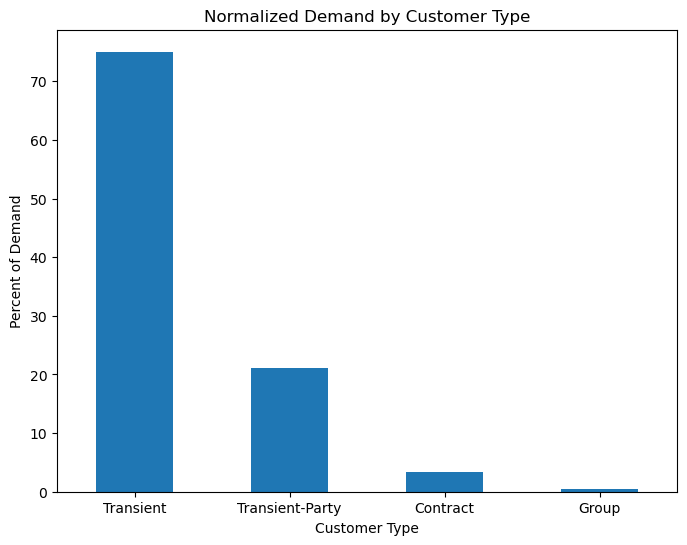

In [144]:
# Demand by customer_type
(clean_df['customer_type'].value_counts(normalize=True) * 100).plot(kind='bar')

plt.title('Normalized Demand by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Percent of Demand')
plt.xticks(rotation=0)
plt.show()


Looking at customer types, I want to combine the two Transient customer_types as well as removing reservations under the Group customer type since there is very few group reservations in this dataset.  Also, in my experience and understanding of Group demand, they are very different to transient demand and therefore I will focus primarily on transient demand only.

I will make these changes in the upcoming feature engineering section.

### <a id='toc2_1_2_'></a>[Market Segment Demand](#toc0_)


In [145]:
# Demand by market_segment
clean_df['market_segment'].value_counts(normalize=True) *100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

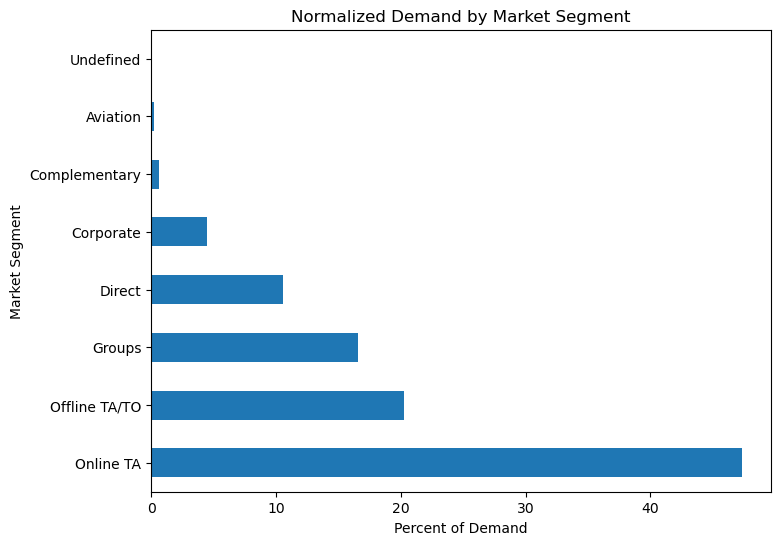

In [146]:
# Demand by market_segment
(clean_df['market_segment'].value_counts(normalize=True) * 100).plot(kind='barh')

plt.title('Normalized Demand by Market Segment')
plt.ylabel('Market Segment')
plt.xlabel('Percent of Demand')

plt.show()


The plot above shows that more than 50% of the demand consists of Travel Agents (Online+Offline).  This is not surprising as the definition of "Travel Agent" has expanded over the years. Online Travel Agents (OTA's) consists of bookings through platforms such as expedia, booking.com, and travelocity.  These are very common sources for travelers to use to explore their options and make hotel as well as airline reservations.

## <a id='toc2_2_'></a>[Additional Cancellations EDA](#toc0_)
- Total Cancellations
- by Market Segment 
- by Customer Type 

### <a id='toc2_2_1_'></a>[Total Cancellations](#toc0_)

In [147]:
# Total Cancellations
total_reservations = clean_df.shape[0]
total_cancelled = clean_df['is_canceled'].value_counts()[1]
total_cancel_pct = clean_df['is_canceled'].value_counts(normalize=True)[1]

print(f'Total Reservations: {total_reservations}')
print(f"Total Canceled Reservations: {total_cancelled}")
print(f"Percentage of Reservations Cancelled: {np.round(total_cancel_pct,4)*100}%")

Total Reservations: 119390
Total Canceled Reservations: 44224
Percentage of Reservations Cancelled: 37.04%


The cancellation percentage may initially feel high, however given my experience in the industry, it's not abnormal to see cancellation percentages this high because this value also includes date changes, no shows, and cancellations.

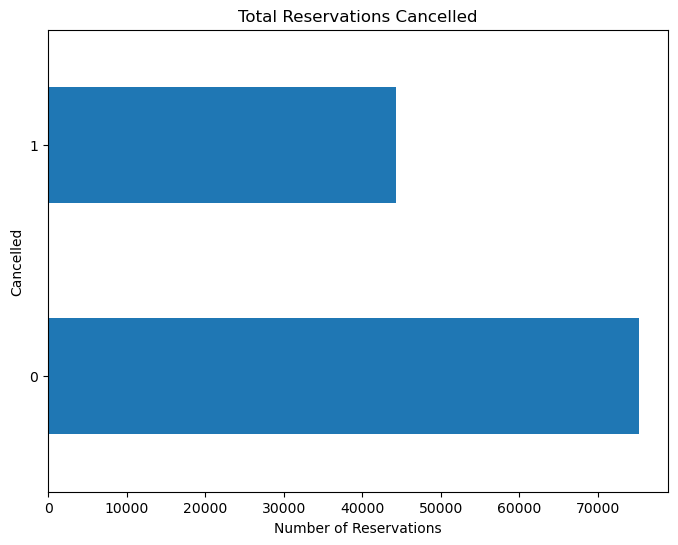

In [148]:
# Total Cancellations
clean_df['is_canceled'].value_counts().plot(kind='barh')

plt.title('Total Reservations Cancelled')
plt.ylabel('Cancelled')
plt.xlabel('Number of Reservations')
plt.show()


In [149]:
#Identifying the the percentage of reservations in the dataset that canceled

clean_df['is_canceled'].value_counts(normalize=True)*100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

For our target, 37% of the reservations in the dataset cancelled which indicates imbalance.

### <a id='toc2_2_2_'></a>[Market Segment Cancellations](#toc0_)

In [150]:
# Creating a DF with market segments by cancellations
segmentation_cxl_df = clean_df.groupby(['market_segment', 'is_canceled']).size().unstack(fill_value=0)
segmentation_cxl_df

is_canceled,0,1
market_segment,,
Aviation,185,52
Complementary,646,97
Corporate,4303,992
Direct,10672,1934
Groups,7714,12097
Offline TA/TO,15908,8311
Online TA,35738,20739
Undefined,0,2


In [151]:
# Adding a cancellation percent to the dataframe
segmentation_cxl_df['cxl_percent'] = np.round(segmentation_cxl_df[1] / (segmentation_cxl_df[1] + segmentation_cxl_df[0])*100, 4)

In [152]:
# Sanity check
segmentation_cxl_df

is_canceled,0,1,cxl_percent
market_segment,,,
Aviation,185,52,21.9409
Complementary,646,97,13.0552
Corporate,4303,992,18.7347
Direct,10672,1934,15.3419
Groups,7714,12097,61.0620
Offline TA/TO,15908,8311,34.3160
Online TA,35738,20739,36.7211
Undefined,0,2,100.0000


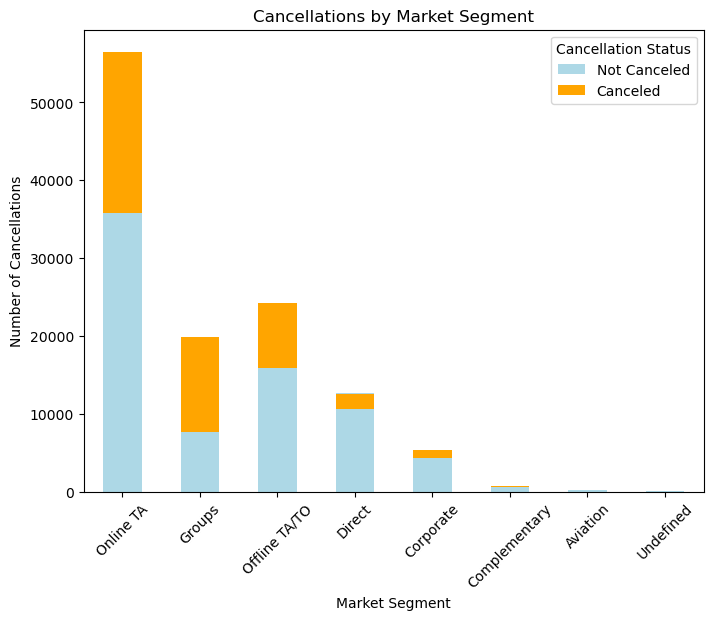

In [153]:
# Cancellations by Market Segment Plot
segmentation_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

Looking at the cancellations by market segments, Online Travel Agents have the largest amount of cancellations and also the 2nd largest cancellation percentage (36%). The market segment with the highest cancellation percentage were groups, with 61%.  This is not surprising since it's common for groups to book a larger number of rooms than needed. Hotel teams are aware of this and a common practice is to "net down" the group block of rooms anticipating that not all the group reservations will materialize.

### <a id='toc2_2_3_'></a>[Customer Type Cancellations](#toc0_)

In [154]:
# Creating a DF with customer type by cancellations
customer_cxl_df = clean_df.groupby(['customer_type', 'is_canceled']).size().unstack(fill_value=0)
customer_cxl_df

is_canceled,0,1
customer_type,,
Contract,2814,1262
Group,518,59
Transient,53099,36514
Transient-Party,18735,6389


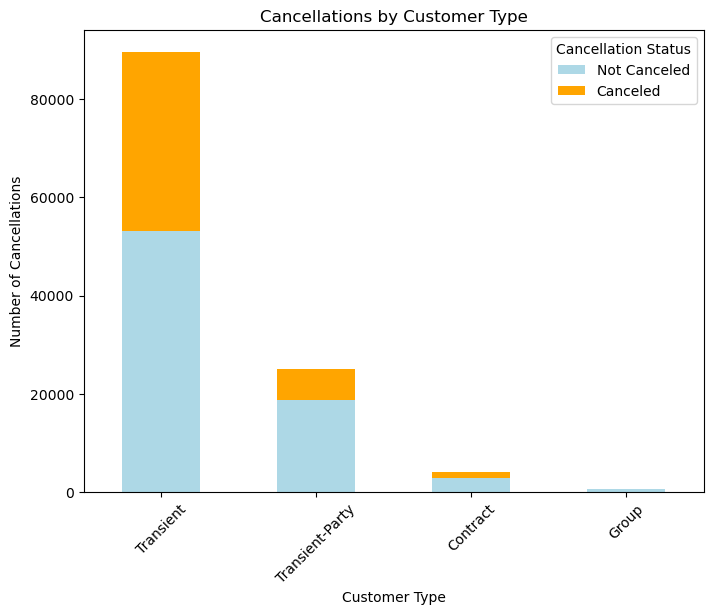

In [155]:
# Cancellations by Customer Type Plot
customer_cxl_df.sort_values(by=1, ascending=False).plot(
    kind='bar', stacked=True,color=['lightblue', 'orange'])

plt.title('Cancellations by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Cancellations')
plt.legend(title='Cancellation Status', labels=['Not Canceled', 'Canceled'])
plt.xticks(rotation=45)
plt.show()

## <a id='toc2_3_'></a>[Booking Window EDA](#toc0_)
- `lead_time` by `customer_type`

In [156]:
clean_df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

The average lead time for bookings are 104 days with the max being 737. That is booking a hotel over 2 years in advanced.

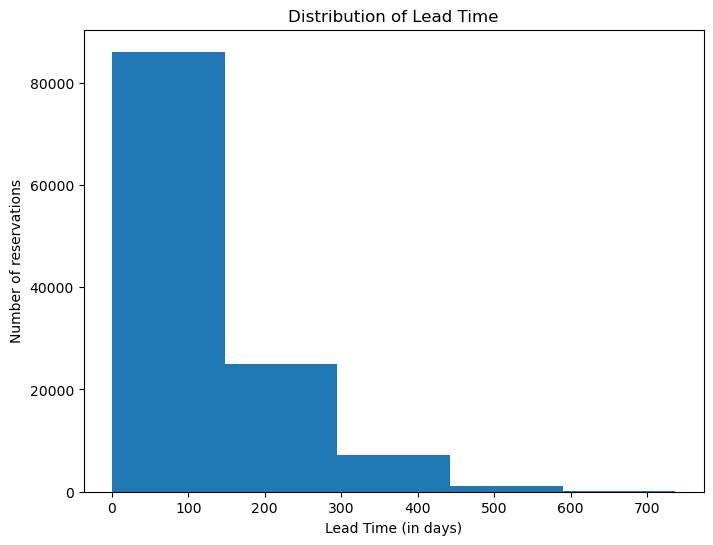

In [157]:
# Plot the distribution of the lead times
clean_df['lead_time'].plot(kind='hist', bins=5)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (in days)')
plt.ylabel('Number of reservations')
plt.show()


In [158]:
# Create lead time ranges 
lead_time_range = [
(None, 7, 'less than 7'),
(7, 14, 'between 7-14'),
(14, 30, 'between 14-30'),
(30, None, 'more than 30')    
]

In [159]:
for lower, upper, label in lead_time_range:
    if lower is None:
        count = clean_df[clean_df['lead_time'] < upper].shape[0]
    elif upper is None:
        count = clean_df[clean_df['lead_time'] >= lower].shape[0]
    else:
        count = clean_df[(clean_df['lead_time'] >= lower) & (clean_df['lead_time'] < upper)].shape[0]
    
    print(f"Number of reservations that booked {label} days in advance: {count}")

Number of reservations that booked less than 7 days in advance: 18415
Number of reservations that booked between 7-14 days in advance: 7392
Number of reservations that booked between 14-30 days in advance: 12240
Number of reservations that booked more than 30 days in advance: 81343


It is surprising to see such a large amount of reservations being booked 30+ days in advanced (68% of total reservations) as well as a large amount of reservations booked within 7 days of arrival (15% of all reservations).

# <a id='toc3_'></a>[Feature Engineering](#toc0_)
1. Group `customer_type` Transient and Transient Party together
2. Remove Group and Contract `customer_type`'s to isolate only Transient
3. Calculate and group Length of Stay into buckets
4. Remove `reservation_status` feature
5. One Hot Encoding for remaining categorical features

## <a id='toc3_1_'></a>[Customer Type Feature Engineering](#toc0_)
Looking at customer types, I will combine the two Transient customer_types and remove reservations under the Group and Contract customer types since there is very few group reservations in this dataset.  Also, with my experience with of Group and Contract demand, they are very different and much harder to predict compared to transient demand. Therefore I will focus primarily on transient demand only.

- Group Customer_Type Transient and Transient Party together
- Isolate only Transient customer_type by removing Group and Contract customer_types 

In [160]:
# Checking customer_type values
clean_df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [161]:
# Change all Transient-Party to be Transient
clean_df['customer_type'].replace('Transient-Party', 'Transient',inplace=True)

In [162]:
# Sanity Check
clean_df['customer_type'].value_counts()

customer_type
Transient    114737
Contract       4076
Group           577
Name: count, dtype: int64

In [163]:
clean_df.shape

(119390, 28)

In [164]:
# Drop all rows containing Contract or Group customer_type
clean_df = clean_df[clean_df['customer_type'] == 'Transient'].reset_index(drop=True)
clean_df

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,day_demand
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,0,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,0,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,122
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,0,No Deposit,1,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,122
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,2015-07-01,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,City Hotel,0,23,35,2,5,2,0,0,1,Offline TA/TO,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,96.14,0,0,Check-Out,2017-09-06,2017-08-30,89
114733,City Hotel,0,102,35,2,5,3,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,225.43,0,2,Check-Out,2017-09-07,2017-08-31,134
114734,City Hotel,0,34,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,157.71,0,4,Check-Out,2017-09-07,2017-08-31,134
114735,City Hotel,0,109,35,2,5,2,0,0,1,Online TA,TA/TO,0,0,0,0,No Deposit,1,0,0,Transient,104.40,0,0,Check-Out,2017-09-07,2017-08-31,134


## <a id='toc3_2_'></a>[Length of Stay Feature Engineering](#toc0_)
- Calculate Length of Stay (los) feature

In [165]:
clean_df[['stays_in_week_nights', 'stays_in_weekend_nights']]

,stays_in_week_nights,stays_in_weekend_nights
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0
...,...,...
114732,5,2
114733,5,2
114734,5,2
114735,5,2


In [166]:
# Add stays_in_weekend_nights + stays_in_week_nights
clean_df['los'] = clean_df['stays_in_week_nights'] + clean_df['stays_in_weekend_nights']

In [167]:
# Sanity check
clean_df['los'].value_counts().head(10)

los
2     26499
3     26457
1     20535
4     16960
7      7782
5      7574
6      3742
8      1119
10      920
9       782
Name: count, dtype: int64

Looking at the value counts for length of stay, over 90,000 of the 114,000 reservations stay between 1-4 nights.

## <a id='toc3_3_'></a>[Remove reservation_status](#toc0_)
Removing `reservation_status` due to the fact that this feature is highly correlated to our target variable `is_canceled` and that it shows what reservations are canceled.

In [168]:
# Drop reservation_status column
clean_df.drop(columns='reservation_status', inplace=True)

## Remove highly correlated features: previous_cancellations

In [ ]:
# Dropping required_car_parking_spaces due to high correlation
clean_df.drop(columns='previous_cancellations', inplace=True)

In [170]:
# Sanity check
clean_df.head()

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,market_segment,distribution_channel,is_repeated_guest,previous_bookings_not_canceled,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los
0,Resort Hotel,0,342,27,0,0,2,0,0,1,Direct,Direct,0,0,3,No Deposit,0,0,0,Transient,0.0,0,0,2015-07-01,2015-07-01,122,0
1,Resort Hotel,0,737,27,0,0,2,0,0,1,Direct,Direct,0,0,4,No Deposit,0,0,0,Transient,0.0,0,0,2015-07-01,2015-07-01,122,0
2,Resort Hotel,0,7,27,0,1,1,0,0,1,Direct,Direct,0,0,0,No Deposit,0,0,0,Transient,75.0,0,0,2015-07-02,2015-07-01,122,1
3,Resort Hotel,0,13,27,0,1,1,0,0,1,Corporate,Corporate,0,0,0,No Deposit,1,0,0,Transient,75.0,0,0,2015-07-02,2015-07-01,122,1
4,Resort Hotel,0,14,27,0,2,2,0,0,1,Online TA,TA/TO,0,0,0,No Deposit,1,0,0,Transient,98.0,0,1,2015-07-03,2015-07-01,122,2


## <a id='toc3_4_'></a>[One Hot Encoding Feature Engineering:](#toc0_)
- hotel
- market_segment
- distribution_channel
- deposit_type
- customer_type


In [171]:
# Instantiate OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

In [172]:
# Fit and transform categorical features in OHE
encoded_array = one_hot_encoder.fit_transform(clean_df[['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type']])
encoded_array

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]])

In [173]:
one_hot_encoder.categories_

[array(['City Hotel', 'Resort Hotel'], dtype=object),
 array(['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups',
        'Offline TA/TO', 'Online TA', 'Undefined'], dtype=object),
 array(['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined'], dtype=object),
 array(['No Deposit', 'Non Refund', 'Refundable'], dtype=object),
 array(['Transient'], dtype=object)]

In [174]:
# Put into a dataframe to get column names
encoded_df = pd.DataFrame(encoded_array, columns=one_hot_encoder.get_feature_names_out(['hotel','market_segment', 'distribution_channel', 'deposit_type', 'customer_type']), dtype=int)

In [175]:
encoded_df.tail()

,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
114732,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
114733,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114734,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114735,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114736,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


In [176]:
final_df = pd.concat([clean_df,encoded_df],axis=1)

In [177]:
# Drop original columns that were used for One Hot Encoding
final_df.drop(columns='hotel',inplace=True)
final_df.drop(columns='market_segment',inplace=True)
final_df.drop(columns='distribution_channel',inplace=True)
final_df.drop(columns='deposit_type',inplace=True)
final_df.drop(columns='customer_type',inplace=True)

In [178]:
# Final dataframe ready for modeling
final_df

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
0,0,342,27,0,0,2,0,0,1,0,0,3,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
1,0,737,27,0,0,2,0,0,1,0,0,4,0,0,0,0.00,0,0,2015-07-01,2015-07-01,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
2,0,7,27,0,1,1,0,0,1,0,0,0,0,0,0,75.00,0,0,2015-07-02,2015-07-01,122,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
3,0,13,27,0,1,1,0,0,1,0,0,0,1,0,0,75.00,0,0,2015-07-02,2015-07-01,122,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1
4,0,14,27,0,2,2,0,0,1,0,0,0,1,0,0,98.00,0,1,2015-07-03,2015-07-01,122,2,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114732,0,23,35,2,5,2,0,0,1,0,0,0,1,0,0,96.14,0,0,2017-09-06,2017-08-30,89,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
114733,0,102,35,2,5,3,0,0,1,0,0,0,1,0,0,225.43,0,2,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114734,0,34,35,2,5,2,0,0,1,0,0,0,1,0,0,157.71,0,4,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
114735,0,109,35,2,5,2,0,0,1,0,0,0,1,0,0,104.40,0,0,2017-09-07,2017-08-31,134,7,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


# <a id='toc4_'></a>[Model Preparation](#toc0_)

1. Train Test Split
2. Scaling

## <a id='toc4_1_'></a>[Train/Test Split](#toc0_)

In [179]:
# Separating X and y target variable (is_canceled)
X = final_df.drop('is_canceled', axis=1)
y = final_df['is_canceled']

In [180]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

In [181]:
y.value_counts()

is_canceled
0    71834
1    42903
Name: count, dtype: int64

In [182]:
# Evaluating the balance of the data set
y.value_counts(normalize=True)*100

is_canceled
0    62.607529
1    37.392471
Name: proportion, dtype: float64

In [183]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24, stratify=y)

In [184]:
np.unique(y_train,return_counts=True)

(array([0, 1]), array([57467, 34322]))

In [185]:
np.unique(y_test,return_counts=True)

(array([0, 1]), array([14367,  8581]))

In [186]:
X_train

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
10417,10,14,1,1,1,0,0,1,0,0,0,0,1,0,45.0,0,0,2017-04-03,2017-04-03,231,2,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1
69810,104,31,0,4,2,0,0,1,0,0,0,1,0,0,125.0,0,2,2017-04-23,2017-08-02,150,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
63046,56,15,2,2,2,1,0,1,0,0,0,1,0,0,144.0,0,0,2017-03-08,2017-04-09,273,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
27719,14,43,0,3,1,0,0,1,0,0,0,1,0,0,66.0,0,1,2016-10-21,2016-10-18,136,3,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
10752,63,16,1,3,1,0,0,1,0,0,1,0,1,0,85.0,0,0,2017-04-12,2017-04-20,158,4,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108565,171,22,0,2,2,0,0,1,0,0,0,1,0,0,126.0,0,0,2017-06-04,2017-06-02,254,2,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
88837,88,30,1,2,3,0,0,1,0,0,0,1,0,0,96.9,0,2,2016-07-21,2016-07-18,184,3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1
42765,99,44,2,2,2,0,0,1,0,0,0,1,0,0,65.0,0,0,2015-10-12,2015-10-30,106,4,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1
46392,85,15,0,3,2,0,0,1,0,0,1,1,0,0,99.3,0,0,2016-03-08,2016-04-07,196,3,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


## <a id='toc4_2_'></a>[Extract features from datetime columns from X_train and X_test](#toc0_)
- arrival_date

Before we can scale, arrival_date and reservation_status_date needs to be transformed since a logistic regression model cannot take datetime

In [187]:
X_train.head(2)

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,arrival_date,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
10417,10,14,1,1,1,0,0,1,0,0,0,0,1,0,45.0,0,0,2017-04-03,2017-04-03,231,2,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1
69810,104,31,0,4,2,0,0,1,0,0,0,1,0,0,125.0,0,2,2017-04-23,2017-08-02,150,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


In [188]:
# Extract year, month, day of month from arrival_date for X_train
X_train['arrival_year'] = X_train['arrival_date'].dt.year
X_train['arrival_month'] = X_train['arrival_date'].dt.month
X_train['arrival_dow'] = X_train['arrival_date'].dt.weekday
X_train['arrival_day'] = X_train['arrival_date'].dt.day

# Extract year, month, day of month from arrival_date for X_test
X_test['arrival_year'] = X_test['arrival_date'].dt.year
X_test['arrival_month'] = X_test['arrival_date'].dt.month
X_test['arrival_dow'] = X_test['arrival_date'].dt.weekday
X_test['arrival_day'] = X_test['arrival_date'].dt.day


Not including Status_Date because of leakage when combined with arrival_date
Also removing date_diff because of leakage

In [189]:
# Extract year, month, day of month from reservation_status_date for X_train
#X_train['status_year'] = X_train['reservation_status_date'].dt.year
#X_train['status_month'] = X_train['reservation_status_date'].dt.month
#X_train['status_dow'] = X_train['reservation_status_date'].dt.weekday
#X_train['status_day'] = X_train['reservation_status_date'].dt.day

# Extract year, month, day of month from reservation_status_date for X_test
#X_test['status_year'] = X_test['reservation_status_date'].dt.year
#X_test['status_month'] = X_test['reservation_status_date'].dt.month
#X_test['status_dow'] = X_test['reservation_status_date'].dt.weekday
#X_test['status_day'] = X_test['reservation_status_date'].dt.day


In [190]:
# Drop original datetime columns for X_train
X_train.drop(columns='reservation_status_date', inplace=True)
X_train.drop(columns='arrival_date',inplace=True)

# Drop original datetime columns for X_test
X_test.drop(columns='reservation_status_date', inplace=True)
X_test.drop(columns='arrival_date',inplace=True)

In [191]:
# Sanity check before scaling
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91789 entries, 10417 to 31982
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   lead_time                       91789 non-null  int64  
 1   arrival_date_week_number        91789 non-null  int64  
 2   stays_in_weekend_nights         91789 non-null  int64  
 3   stays_in_week_nights            91789 non-null  int64  
 4   adults                          91789 non-null  int64  
 5   children                        91789 non-null  int64  
 6   babies                          91789 non-null  int64  
 7   meal                            91789 non-null  int64  
 8   is_repeated_guest               91789 non-null  int64  
 9   previous_bookings_not_canceled  91789 non-null  int64  
 10  booking_changes                 91789 non-null  int64  
 11  agent                           91789 non-null  int64  
 12  company                         9

# Handling the Class Imbalance

 The imbalance is 37% class 1 and 63% class 0. Through exploration, I discovered that without imbalancing, there is severe overfitting on the baseline models. Therefore, before scaling the data, I need to handle the class imbalance by applying SMOTE.

## Applying SMOTE

1. Instantiate SMOTE sampler, fit it to the training data, then resample the data
2. Scale the sampled train data and the unsampled test data
3. Instantiate and fit to scaled & balanced training data for baseline models
4. Make Predictions and evaluate with new balanced data

In [192]:
# Step 1: Instantiate SMOTE
smote = SMOTE(random_state=24)

# Fit training data and Resample
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Check what SMOTE has done
print('Original class distribution')
display(pd.Series(y_train).value_counts().sort_index())

print('\nResampled class distribution')
display(pd.Series(y_train_sm).value_counts().sort_index())

Original class distribution


is_canceled
0    57467
1    34322
Name: count, dtype: int64


Resampled class distribution


is_canceled
0    57467
1    57467
Name: count, dtype: int64

### <a id='toc4_3_'></a>[Scaling](#toc0_)

In [193]:
# STEP 2: Scale the sampled train data and the unsampled test data
ss_sm = StandardScaler().fit(X_train_sm)
X_train_sm_ss = ss_sm.transform(X_train_sm)
X_test_ss_sm = ss_sm.transform(X_test)

# Baseline Models


#### Logistic Regression Balanced

In [194]:
# Instantiate the model
log_reg_sm = LogisticRegression()

# Fit the model
log_reg_sm.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred=log_reg_sm.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {log_reg_sm.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {log_reg_sm.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred)*100:0.2f}%')

Train score: 79.90%
Test score: 77.97%
Precision score: 72.92%
Recall score: 65.34%
F1 score: 68.92%


/Users/brianlui/anaconda3/envs/rm_system/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


| Model              | Train Score | Test Score | Precision | Recall  | f1-score |
|--------------------|-------------|------------|-----------|---------|----------|
| log_reg_sm         | 79.90%      | 77.97%     | 72.92%    | 65.34%  | 68.92%   |


The baseline logistic regression model is showing a ~78% accuracy score with slight overfitting since the train score is ~80%. The model is providing higher precision than recall with an f1-score of only ~69%.


In [293]:
# Checking coefficients values
pd.DataFrame({'coeff': log_reg_sm.coef_[0]}, index=X_train.columns).sort_values('coeff')

,coeff
stays_in_week_nights,-8.386173
stays_in_weekend_nights,-4.575644
hotel_City Hotel,-3.089441
hotel_Resort Hotel,-3.019329
market_segment_Offline TA/TO,-2.526063
market_segment_Online TA,-2.431141
required_car_parking_spaces,-2.411787
market_segment_Groups,-2.259206
deposit_type_No Deposit,-2.202443
distribution_channel_TA/TO,-2.081585


#### Random Forest Balanced

In [195]:
# Instantiate random forest
random_forest_sm = RandomForestClassifier(n_estimators=100) # instantiating and picking to train 100 DT models which is the default

# Fit the random forest model
random_forest_sm.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred=random_forest_sm.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {random_forest_sm.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {random_forest_sm.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred)*100:0.2f}%')

Train score: 99.08%
Test score: 85.75%
Precision score: 83.57%
Recall score: 77.03%
F1 score: 80.16%


| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators |
|--------------------|-------------|------------|-----------|---------|----------|--------------|
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   | 1000         |



The baseline random forest model is showing a 85% accuracy score with overfitting since the train score is 99%. The model is providing higher precision than recall as well, with an f1-score of only 80%.


#### XGBoost Balanced

In [196]:
# Instantiate XGBoost
XGBoost_model_sm = XGBClassifier() 
XGBoost_model_sm.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred=XGBoost_model_sm.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {XGBoost_model_sm.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {XGBoost_model_sm.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred)*100:0.2f}%')

Train score: 86.44%
Test score: 82.90%
Precision score: 79.54%
Recall score: 73.07%
F1 score: 76.17%


| Model              | Train Score | Test Score | Precision | Recall  | f1-score |
|--------------------|-------------|------------|-----------|---------|----------|
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   |





The baseline XGBoost model is showing a ~83% accuracy score with slight overfitting with the train score being 86%. The model is providing higher precision than recall as well, with an f1-score of only 76%.


| Model              | Train Score | Test Score | Precision | Recall  | f1-score |
|--------------------|-------------|------------|-----------|---------|----------|
| log_reg_sm         | 79.90%      | 77.97%     | 72.92%    | 65.34%  | 68.92%   |
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   |
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   |




Based on the three baseline models, the random_forest model has the highest test score and f1 score, however it has the highest overfitting with a 99% train score.  Next I will apply hyperparameters for each model to see if I can increase model performance.

# Parameter Tuned Models

### <a id='toc5_1_'></a>[Logistic Regression Hyperparameter Tuning](#toc0_)

#### <a id='toc11_3_'></a>[Hyperparameter optimization for C](#toc0_)

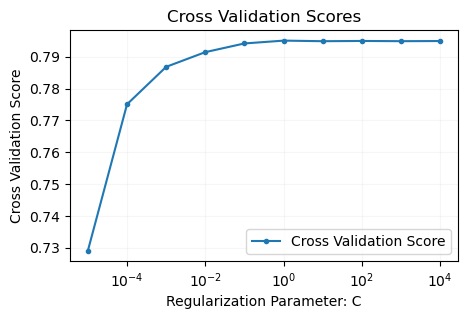

The best model has C =  1.0


In [203]:
#Use Cross Validation to find the best C value

# Store the results
cross_validation_scores = []

# Create an array of powers of ten for the values of inverse regularization strength C
C_range = 10 ** np.array(range(-5, 5), dtype=float)

# Perform cross validation
for C in C_range:
    model = LogisticRegression(C=C, random_state=24, max_iter=1000)

    # The cross validation score (mean of scores from all folds)
    cv_score = np.mean(cross_val_score(model, X_train_sm_ss, y_train_sm, cv=5))

    # Append the score
    cross_validation_scores.append(cv_score)

plt.figure(figsize=(5,3))
plt.plot(C_range, cross_validation_scores, label="Cross Validation Score", marker=".")
plt.xscale("log")
plt.grid(alpha=0.1)
plt.xlabel("Regularization Parameter: C")
plt.ylabel("Cross Validation Score")
plt.title("Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal C
index_of_max = np.array(cross_validation_scores).argmax()
print("The best model has C = ", C_range[index_of_max])

#### Manual Hyperparameter Logistic Regression Model (log_reg_sm2)

Optimized hyperparameter C with logistic regression

In [301]:
# Instantiate the model
log_reg_sm2 = LogisticRegression(C=1, max_iter=1000)

# Perform 5-fold cross-validation for train
scores = cross_val_score(log_reg_sm2, X_train_sm_ss, y_train_sm, cv=5)
print(f"Cross-validation scores: {np.mean(scores)}")

# Fit the model
log_reg_sm2.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred_sm2=log_reg_sm2.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {log_reg_sm2.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {log_reg_sm2.score(X_test_ss_sm, y_test)*100:0.2f}%')

print(f'Precision score: {precision_score(y_test, y_test_pred_sm2)*100:0.2f}%')

print(f'Recall score: {recall_score(y_test, y_test_pred_sm2)*100:0.2f}%')

print(f'F1 score: {f1_score(y_test, y_test_pred_sm2)*100:0.2f}%')

Cross-validation scores: 0.7950742449955193
Train score: 79.91%
Test score: 77.94%
Precision score: 72.85%
Recall score: 65.38%
F1 score: 68.91%


The additional C values and max_iter did not seem to impact the model results much. There was slight changes but insignificant. Next I will attemp PCA to see if there is any changes to the model performance.

| Model        | Train Score | Test Score | Precision | Recall | f1-score | Hyperparameter C | K-Fold Cross Val (k) | Max_Iter | PCA |
|--------------|-------------|------------|-----------|--------|----------|------------------|----------------------|----------|-----|
| log_reg_sm   | 79.90%      | 77.97%     | 72.92%    | 65.34% | 68.92%   | -                | -                    | -        | N   |
| log_reg_sm2  | 79.50%      | 77.94%     | 72.85%    | 65.38% | 68.91%   | C=1              | 5                    | 1000     | N   |


#### <a id='toc11_4_'></a>[PCA with Logistic Regression model](#toc0_)
- Attempting Principal Component Analysis with the same hyperparameters as log_reg2 model to see if model scores improve by reducing the dimensionality, but keeping as much variation as possible.

In [200]:
# Create the PCA object
PCA_object = PCA()

# Fit the PCA object to the data
PCA_object.fit(X_train_sm_ss)

# Transform the original data
X_PCA_train = PCA_object.transform(X_train_sm_ss)
X_PCA_test = PCA_object.transform(X_test_ss_sm)

In [299]:
# Instantiate
log_reg_sm3 = LogisticRegression(C=1, max_iter=1000)

# Fit logreg model to X_train
log_reg_sm3.fit(X_PCA_train, y_train_sm)

# Scoring the logreg model
print(f' Train score: {log_reg_sm3.score(X_PCA_train, y_train_sm)}')
print(f' Test score: {log_reg_sm3.score(X_PCA_test, y_test)}')

# predict classification
y_test_pred_sm3 = log_reg_sm3.predict(X_PCA_test)

# Score the train set
print(f'Train score: {log_reg_sm3.score(X_PCA_train, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {log_reg_sm3.score(X_PCA_test, y_test)*100:0.2f}%')

print(f'Precision score: {precision_score(y_test, y_test_pred_sm3)*100:0.2f}%')

print(f'Recall score: {recall_score(y_test, y_test_pred_sm3)*100:0.2f}%')

print(f'F1 score: {f1_score(y_test, y_test_pred_sm3)*100:0.2f}%')

 Train score: 0.7990411888562131
 Test score: 0.7794579048283075
Train score: 79.90%
Test score: 77.95%
Precision score: 72.86%
Recall score: 65.38%
F1 score: 68.91%


After manually optimizing a C hyperparameter, K Fold Cross validation, and PCA, the overall accuracy of logistic regression did not improve. The f1-scores also remained the same.  

I will continue exploring the other two models as they had higher metrics and may provide more promising results. 

| Model        | Train Score | Test Score | Precision | Recall | f1-score | Hyperparameter C | K-Fold Cross Val (k) | Max_Iter | PCA |
|--------------|-------------|------------|-----------|--------|----------|------------------|----------------------|----------|-----|
| log_reg_sm   | 79.90%      | 77.97%     | 72.92%    | 65.34% | 68.92%   | -                | -                    | -        | N   |
| log_reg_sm2  | 79.50%      | 77.94%     | 72.85%    | 65.38% | 68.91%   | C=1              | 5                    | 1000     | N   |
| log_reg_sm3  | 79.90%      | 77.95%     | 72.86%    | 65.38% | 68.91%   | C=1              | -                    | 1000     | Y   |



## Random Forest Hyperparameter Tuning

Based on manual hyperparameter optimization (see appendix), I will run a new random forest model with the identified optimal hyperparameters.


### Manual Hyperparameter Optimization Random Forest Model (random_forest_sm2)

In [281]:
# Instantiate random forest
random_forest_sm2 = RandomForestClassifier(n_estimators=1500, 
                                        max_depth=9, 
                                        min_samples_split=72, 
                                        min_samples_leaf=16,
                                        random_state=24,
                                        class_weight='balanced') 

# Fit the random forest model
random_forest_sm2.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred_rf2=random_forest_sm2.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {random_forest_sm2.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {random_forest_sm2.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred_rf2)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred_rf2)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred_rf2)*100:0.2f}%')

Train score: 80.24%
Test score: 79.81%
Precision score: 77.74%
Recall score: 64.44%
F1 score: 70.47%


Random forest model with manual hyperparameters has decreased the overfitting significantly, however there is a 10% drop in f1-score where Recall decreased the most by 13%

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | min_samples_split | min_samples_leaf | class_weight |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|-------------------|------------------|--------------|
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   | 1000         | -         | -                 | -                | -            |
| random_forest_sm2  | 80.24%      | 79.80%     | 77.74%    | 64.44%  | 70.47%   | 1500         | 9         | 72                | 16               | balanced     |




### <a id='toc6_1_'></a>[Grid Search for Random Forest Hyperparameters](#toc0_)


In [ ]:
#Creating pipeline for grid search
rf_estimators = [('random_forest', RandomForestClassifier())]
rf_pipe = Pipeline(rf_estimators)

#hyperparameters to search
rf_params = {'random_forest__n_estimators': [200, 1500], # testing with just 100 and 200 first to prevent overfitting
             'random_forest__max_depth': [9, 11],
             'random_forest__min_samples_split': [72, 60],
             'random_forest__min_samples_leaf': [1, 16]}

rf_grid_search = GridSearchCV(rf_pipe, 
                              param_grid=rf_params,
                              cv = 3,
                              verbose=2,#show progress of the grid search
                              n_jobs=-1) #parallel computations and use multiple cores 

rf_fitted_search = rf_grid_search.fit(X_train_sm_ss, y_train_sm)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


#### <a id='toc6_1_1_'></a>[Save and Reload grid search results](#toc0_)

Saving and reloading grid search results because it took almost 800 minutes to complete.

In [ ]:
# Save grid search results
#joblib.dump(rf_fitted_search, 'rf_fitted_search.pkl')

# reload grid search results
rf_fitted_search = joblib.load('../data/rf_fitted_search.pkl')


['rf_fitted_search.pkl']

In [283]:
print("Best Random Forest Parameters:", rf_fitted_search.best_params_)
print("Best Cross-Validation Accuracy:", rf_fitted_search.best_score_)

Best Random Forest Parameters: {'random_forest__max_depth': 11, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 60, 'random_forest__n_estimators': 1500}
Best Cross-Validation Accuracy: 0.8081684630222351


Grid Search Results for Best Hyperparameters for Random Forest:
- max_depth: 11
- min_samples leaf: 1
- min_samples split: 60
- n_estimators: 1500

### <a id='toc6_2_'></a>[Grid Searched HyperParameters Random Forest Model random_forest_sm3 ](#toc0_)

In [292]:
# Instantiate random forest
random_forest_sm3 = RandomForestClassifier(n_estimators=1500, 
                                        max_depth=11, 
                                        min_samples_split=60, 
                                        min_samples_leaf=1,
                                        random_state=24,
                                        class_weight='balanced') 

# Fit the random forest model
random_forest_sm3.fit(X_train_sm_ss, y_train_sm)

# predict classification
y_test_pred_rf3=random_forest_sm3.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {random_forest_sm3.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {random_forest_sm3.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred_rf3)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred_rf3)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred_rf3)*100:0.2f}%')

Train score: 81.91%
Test score: 80.80%
Precision score: 78.58%
Recall score: 66.88%
F1 score: 72.26%


The random forest model with the gridsearched hyperparameters showed a 1% increase in accuracy and a ~2% increase in f1-score.

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | min_samples_split | min_samples_leaf | class_weight |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|-------------------|------------------|--------------|
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   | 1000         | -         | -                 | -                | -            |
| random_forest_sm2  | 80.24%      | 79.80%     | 77.74%    | 64.44%  | 70.47%   | 1500         | 9         | 72                | 16               | balanced     |
| random_forest_sm3  | 81.91%      | 80.80%     | 78.58%    | 66.88%  | 72.26%   | 1500         | 11        | 60                | 1                | balanced     |





The random forest model with the hyperparameters from the grid search are a lot more promising and are not overfitted.  I will take the random_forest2 model to evaluate the model further

## XGBoost Model with Hyperparameter Tuning

In [269]:
# Instantiate XGBoost
XGBoost_model_sm2 = XGBClassifier(n_estimators= 400,
                                  learning_rate=0.1,
                                  max_depth=7,
                                  eval_metric='auc') 
XGBoost_model_sm2.fit(X_train_sm_ss, y_train_sm,
                      eval_set=[(X_test_ss_sm, y_test)],
                      verbose=True)

# predict classification
y_test_pred_xgb2=XGBoost_model_sm2.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {XGBoost_model_sm2.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {XGBoost_model_sm2.score(X_test_ss_sm, y_test)*100:0.2f}%')
print(f'Precision score: {precision_score(y_test,y_test_pred_xgb2)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_test_pred_xgb2)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_test_pred_xgb2)*100:0.2f}%')

[0]	validation_0-auc:0.84541
[1]	validation_0-auc:0.84713
[2]	validation_0-auc:0.84976
[3]	validation_0-auc:0.85058
[4]	validation_0-auc:0.85313
[5]	validation_0-auc:0.85344
[6]	validation_0-auc:0.85513
[7]	validation_0-auc:0.85625
[8]	validation_0-auc:0.85601
[9]	validation_0-auc:0.85742
[10]	validation_0-auc:0.85785
[11]	validation_0-auc:0.85941
[12]	validation_0-auc:0.86018
[13]	validation_0-auc:0.86052
[14]	validation_0-auc:0.86147
[15]	validation_0-auc:0.86224
[16]	validation_0-auc:0.86275
[17]	validation_0-auc:0.86375
[18]	validation_0-auc:0.86410
[19]	validation_0-auc:0.86453
[20]	validation_0-auc:0.86497
[21]	validation_0-auc:0.86532
[22]	validation_0-auc:0.86566
[23]	validation_0-auc:0.86656
[24]	validation_0-auc:0.86683
[25]	validation_0-auc:0.86739
[26]	validation_0-auc:0.86823
[27]	validation_0-auc:0.86846
[28]	validation_0-auc:0.86920
[29]	validation_0-auc:0.86955
[30]	validation_0-auc:0.86996
[31]	validation_0-auc:0.87014
[32]	validation_0-auc:0.87058
[33]	validation_0-au

The XGBoost model with hyperparameters added increased the accuracy and f1-score only slightly by 1%. However, the model is now slightly more overfitted compared to the baseline model by ~1.5%.

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | learning_rate | eval_metric |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|---------------|-------------|
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   | -            | -         | -             | -           |
| XGBoost_model_sm2  | 88.98%      | 83.86%     | 81.04%    | 74.20%  | 77.47%   | 400          | 7         | 0.1           | auc         |


### Grid Search for optimial Hyperparameters for XGBoost Model


In [294]:
#Creating pipeline for grid search
XGB_estimators = [('XGBoost', XGBClassifier(eval_metric='auc'))]
XGB_pipe = Pipeline(XGB_estimators)

#hyperparameters to search
XGB_params = {'XGBoost__n_estimators': [100, 200, 300], 
             'XGBoost__max_depth': [3, 5, 7],
             'XGBoost__learning_rate': [0.01, 0.1, 0.2]}

XGB_grid_search = GridSearchCV(XGB_pipe, 
                              param_grid=XGB_params,
                              scoring='accuracy',
                              cv = 3,
                              verbose=2,#show progress of the grid search
                              n_jobs=-1) #parallel computations and use multiple cores 

XGB_fitted_search = XGB_grid_search.fit(X_train_sm_ss, y_train_sm)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


AttributeError: 'XGBModel' object has no attribute 'feature_weights'

### Grid Searched Hyperparameter XGBoost Model XGBoost_model_sm3

In [ ]:
# Instantiate XGBoost
XGBoost_model_sm3 = XGBClassifier(n_estimators= 300,
                                  learning_rate=0.2,
                                  max_depth=7,
                                  eval_metric='auc') 
XGBoost_model_sm3.fit(X_train_sm_ss, y_train_sm,
                      eval_set=[(X_test_ss_sm, y_test)],
                      verbose=True)

# predict classification
y_test_pred_xgb3=XGBoost_model_sm3.predict(X_test_ss_sm)

# Score the train set
print(f'Train score: {XGBoost_model_sm3.score(X_train_sm_ss, y_train_sm)*100:0.2f}%')

# Evaluate the test set
print(f'Test score: {XGBoost_model_sm3.score(X_test_ss_sm, y_test)*100:0.2f}%')

print(f'Precision score: {precision_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

print(f'Recall score: {recall_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

print(f'F1 score: {f1_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

[0]	validation_0-auc:0.84541
[1]	validation_0-auc:0.85042
[2]	validation_0-auc:0.85274
[3]	validation_0-auc:0.85436
[4]	validation_0-auc:0.85864
[5]	validation_0-auc:0.86028
[6]	validation_0-auc:0.86124
[7]	validation_0-auc:0.86211
[8]	validation_0-auc:0.86329
[9]	validation_0-auc:0.86402
[10]	validation_0-auc:0.86525
[11]	validation_0-auc:0.86606
[12]	validation_0-auc:0.86700
[13]	validation_0-auc:0.86831
[14]	validation_0-auc:0.86915
[15]	validation_0-auc:0.86989
[16]	validation_0-auc:0.87154
[17]	validation_0-auc:0.87219
[18]	validation_0-auc:0.87259
[19]	validation_0-auc:0.87324
[20]	validation_0-auc:0.87367
[21]	validation_0-auc:0.87423
[22]	validation_0-auc:0.87502
[23]	validation_0-auc:0.87559
[24]	validation_0-auc:0.87572
[25]	validation_0-auc:0.87647
[26]	validation_0-auc:0.87701
[27]	validation_0-auc:0.87781
[28]	validation_0-auc:0.87826
[29]	validation_0-auc:0.87874
[30]	validation_0-auc:0.87957
[31]	validation_0-auc:0.88011
[32]	validation_0-auc:0.88058
[33]	validation_0-au

The gridsearched hyperparameter model (XGBoost_model_sm3) resulted in another ~1% increase in f1-score similar to previous model run, however it is the most overfitted with the train score being almost 6.5% higher than test score.

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | learning_rate | eval_metric |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|---------------|-------------|
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   |              |           |               |             |
| XGBoost_model_sm2  | 88.98%      | 83.86%     | 81.04%    | 74.20%  | 77.47%   | 400          | 7         | 0.1           | auc         |
| XGBoost_model_sm3  | 90.80%      | 84.33%     | 81.56%    | 75.07%  | 78.18%   | 300          | 7         | 0.2           | auc         |


## <a id='toc7_'></a>[Model Comparison](#toc0_)

Before looking at further model evaluation, here is a summary table of the models run so far:


| Model         | Train Score | Test Score | Hyperparameter C | K-Fold Cross Val | Max Iter | PCA |
|---------------|-------------|------------|------------------|------------------|----------|-----|
| log_reg_sm    | 79.90%      | 77.97%     | -                |   -              | -        | N   |
| log_reg_sm2   | 79.50%      | n/a        | C=1              |   5              | 1000     | N   |
| log_reg_sm3   | 79.90%      | 77.94%     | C=1              |   -              | 1000     | Y   |

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | min_samples_split | min_samples_leaf | class_weight |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|-------------------|------------------|--------------|
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   | 1000         | -         | -                 | -                | -            |
| random_forest_sm2  | 80.24%      | 79.80%     | 77.74%    | 64.44%  | 70.47%   | 1500         | 9         | 72                | 16               | balanced     |
| random_forest_sm3  | 81.91%      | 80.80%     | 78.58%    | 66.88%  | 72.26%   | 1500         | 11        | 60                | 1                | balanced     |

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | learning_rate | eval_metric |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|---------------|-------------|
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   |              |           |               |             |
| XGBoost_model_sm2  | 88.98%      | 83.86%     | 81.04%    | 74.20%  | 77.47%   | 400          | 7         | 0.1           | auc         |
| XGBoost_model_sm3  | 90.80%      | 84.33%     | 81.56%    | 75.07%  | 78.18%   | 300          | 7         | 0.2           | auc         |

My goal is to identify models with the least overfitting and high f1-scores. Based on the models, for my next steps I will evaluate the random_forest_sm3 and XGBoost_model_sm baseline models further. 
1. ROC and AUC for random_forest_sm3
2. ROC and AUC for XGBoost_model_sm

### <a id='toc7_1_'></a>[Model Evaluation of random_forest_sm3](#toc0_)

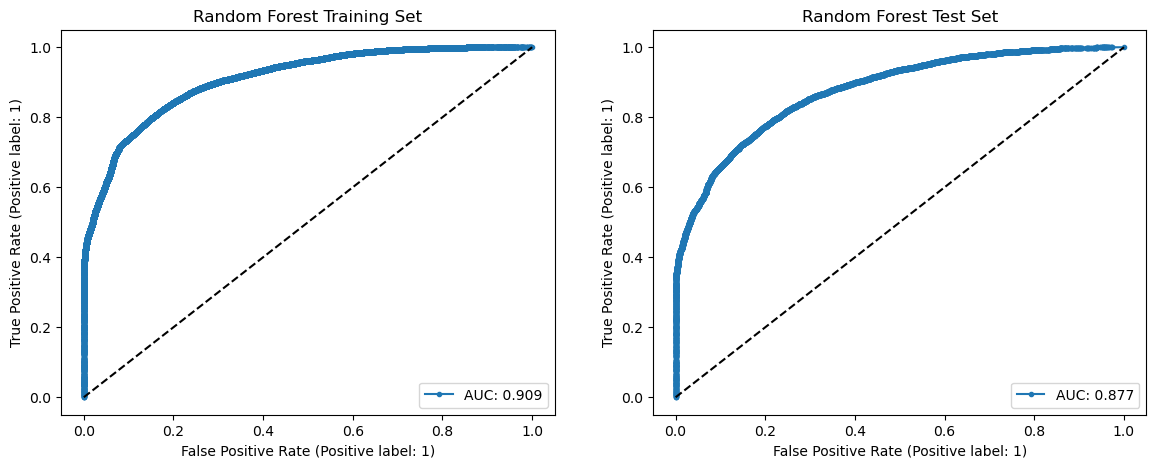

Training Set AUC: 0.909
Test Set AUC: 0.877


In [304]:
#Predict probabilities
y_proba_train = random_forest_sm3.predict_proba(X_train_sm_ss)[:,1]
y_proba_test = random_forest_sm3.predict_proba(X_test_ss_sm)[:,1]

# Score (AUC)
rf_auc_train = np.round(roc_auc_score(y_train_sm, y_proba_train),3)
rf_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {rf_auc_train}"
test_label = f"AUC: {rf_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(random_forest_sm3, X_train_sm_ss, y_train_sm, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(random_forest_sm3, X_test_ss_sm, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("Random Forest Training Set")
axes[1].set_title("Random Forest Test Set")


plt.show()

print(f"Training Set AUC: {rf_auc_train}")
print(f"Test Set AUC: {rf_auc_test}")

The area under the curve (AUC) for the random_forest_sm3 model is 87.7% with slight overfitting.

### <a id='toc7_2_'></a>[Model Evaluation of XGBoost_model_sm](#toc0_)

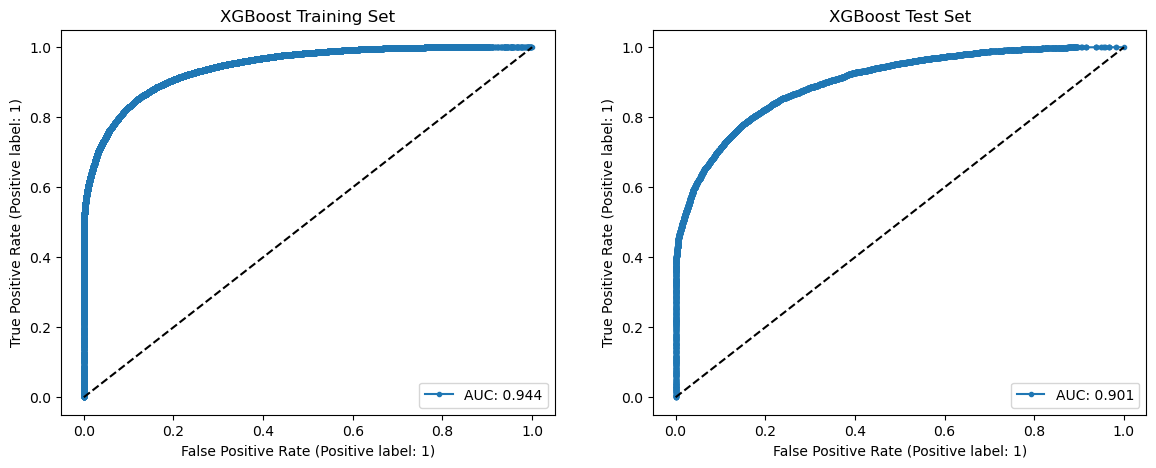

Training Set AUC: 0.944
Test Set AUC: 0.901


In [306]:
#Predict probabilities
y_proba_train = XGBoost_model_sm.predict_proba(X_train_sm_ss)[:,1]
y_proba_test = XGBoost_model_sm.predict_proba(X_test_ss_sm)[:,1]

# Score (AUC)
xgb_auc_train = np.round(roc_auc_score(y_train_sm, y_proba_train),3)
xgb_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {xgb_auc_train}"
test_label = f"AUC: {xgb_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(XGBoost_model_sm, X_train_sm_ss, y_train_sm, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(XGBoost_model_sm, X_test_ss_sm, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("XGBoost Training Set")
axes[1].set_title("XGBoost Test Set")


plt.show()

print(f"Training Set AUC: {xgb_auc_train}")
print(f"Test Set AUC: {xgb_auc_test}")

The area under the curve (AUC) for the XGBoost model is 90.10% with slight overfitting as well.

Comparing the models overall scores:

| Model            | Train AUC | Test AUC | Train Score | Test Score | Precision | Recall  | f1-score |
|------------------|-----------|----------|-------------|------------|-----------|---------|----------|
| random_forest_sm3| 90.90%    | 87.70%   | 81.91%      | 80.80%     | 78.58%    | 66.88%  | 72.26%   |
| XGBoost_model_sm | 94.40%    | 90.10%   | 90.80%      | 84.33%     | 81.56%    | 75.07%  | 78.18%   |



Of my two models, the XGBoost model is showing higher overfitting for both AUC and accuracy scores, but provides a higher f1-score.  The f1-score listed here is for the test set. I will run f1-scores for both train set's to see how the overfitting compares next.

### Compare F1-scores overfitting

In [311]:
# Random Forest Model predict classification
y_train_pred_rf3 = random_forest_sm3.predict(X_train_sm_ss)
y_test_pred_rf3 = random_forest_sm3.predict(X_test_ss_sm)

# Precision
print(f'Precision Train score: {precision_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'Precision Test score: {precision_score(y_test, y_test_pred_rf3)*100:0.2f}%')

# Recall
print(f'Recall Train score: {recall_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'Recall Test score: {recall_score(y_test, y_test_pred_rf3)*100:0.2f}%')

# F1-score
print(f'F1 Train score: {f1_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'F1 Test score: {f1_score(y_test, y_test_pred_rf3)*100:0.2f}%')

Precision Train score: 87.58%
Precision Test score: 78.58%
Recall Train score: 74.38%
Recall Test score: 66.88%
F1 Train score: 80.44%
F1 Test score: 72.26%


In [310]:
# XGBoost Model predict classification
y_train_pred_xgb3 = XGBoost_model_sm3.predict(X_train_sm_ss)
y_test_pred_xgb3 = XGBoost_model_sm3.predict(X_test_ss_sm)

# Precision
print(f'Precision Train score: {precision_score(y_train_sm, y_train_pred_xgb3)*100:0.2f}%')
print(f'Precision Test score: {precision_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

# Recall
print(f'Recall Train score: {recall_score(y_train_sm, y_train_pred_xgb3)*100:0.2f}%')
print(f'Recall Test score: {recall_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

# F1-score
print(f'F1 Train score: {f1_score(y_train_sm, y_train_pred_xgb3)*100:0.2f}%')
print(f'F1 Test score: {f1_score(y_test, y_test_pred_xgb3)*100:0.2f}%')

Precision Train score: 92.81%
Precision Test score: 81.56%
Recall Train score: 88.45%
Recall Test score: 75.07%
F1 Train score: 90.58%
F1 Test score: 78.18%


### Comparing Overfitting between Random Forest and XGBoost models:

**random_forest_sm3 Model:**

| Metric     | Train   | Test    | Overfitted Amount |
|------------|---------|---------|-------------------|
| Accuracy   | 81.91%  | 80.80%  | 1.11%             |
| AUC        | 90.90%  | 87.70%  | 3.20%             |
| Precision  | 87.58%  | 78.58%  | 9.00%             |
| Recall     | 74.38%  | 66.88%  | 7.50%             |
| F1 Score   | 80.44%  | 72.26%  | 8.18%             |


**XGBoost_model_sm Model:**

| Metric     | Train   | Test    | Overfitted Amount |
|------------|---------|---------|-------------------|
| Accuracy   | 90.80%  | 84.33%  | 6.47%             |
| AUC        | 94.40%  | 90.10%  | 4.30%             |
| Precision  | 92.81%  | 81.56%  | 11.25%            |
| Recall     | 88.45%  | 75.07%  | 13.38%            |
| F1 Score   | 90.58%  | 78.18%  | 12.40%            |


A model that has higher overfitting is tailoring itself too closely to the training data and therefore may not perform as well on unseen data. This could lead to unreliable predictions.
Therefore based on the overfitting between the two models, although XGBoost had a higher F1 score, accuracy, and AUC scores, it is overfitting more across all metrics compared to the random forest model.

The random forest model only is marginally lower in accuracy by 4%, AUC by ~3%, and F1-score by 6%.  The largest difference is that the random forest model is 9% lower in recall compared to the XGBoost model. However, it has much less overfitting and suggest that it will likely perform more consistentl on new data.

# Error Analysis

Moving foward with the Random Forest Model, evaluating tha confusion matrix will identify where the model is struggling the most. I may be able to identify patterns that indicate bias.

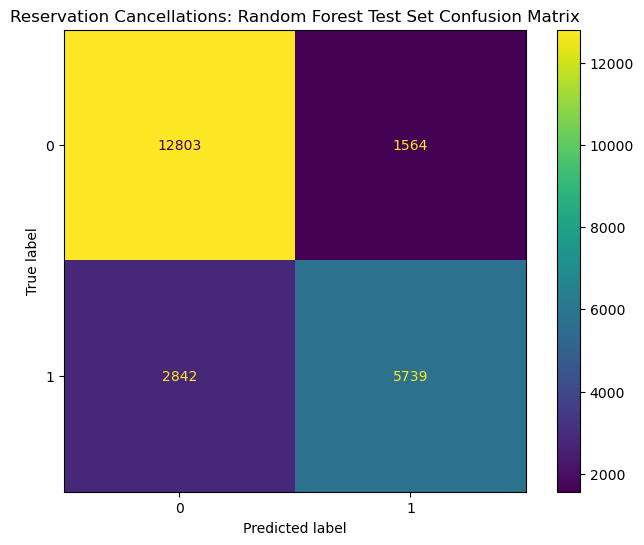

In [312]:
# Instantiate Confusion Matrix for Random Forest Model
ConfusionMatrixDisplay.from_estimator(random_forest_sm3, X_test_ss_sm, y_test)

plt.title('Reservation Cancellations: Random Forest Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 14,000 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: only ~300 of the reservations that the model predicted to cancel, did not cancel
- **False Negatives**: 2700 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: 5800 of the cancelled reservations were correctly predicted out of the 8500 total cancellations

In [ ]:
# Get class predictions for random_forest_sm3
y_pred_rf = random_forest_sm3.predict(X_test_ss_sm)

rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     14367
           1       0.79      0.67      0.72      8581

    accuracy                           0.81     22948
   macro avg       0.80      0.78      0.79     22948
weighted avg       0.81      0.81      0.80     22948



# Feature Importance

### <a id='toc8_1_'></a>[Random Forest Feature Importance:](#toc0_)

In [315]:
%%time

# Determine random forest feature importance using the test set
# Repeat the permuation step 5 times per column.
rf_result = permutation_importance(random_forest_sm3, X_test_ss_sm, y_test, n_repeats=5, random_state=0)

CPU times: user 5min 25s, sys: 1.36 s, total: 5min 26s
Wall time: 5min 29s


In [316]:
# Calculate the average importance per feature for Random Forest Model
importances = rf_result.importances_mean

# Normalize the importances
normalized_importances = importances / importances.sum()


# Put the variable names and their feature importances into a data frame
rf_permute_importances_df = pd.DataFrame({'Variable': X_train.columns,
                               'Importance': importances,
                               'Normalized Importance': normalized_importances})

rf_permute_importances_df.sort_values(by='Importance', ascending=False, inplace=True, ignore_index=True)

rf_permute_importances_df

,Variable,Importance,Normalized Importance
0,total_of_special_requests,0.071248,0.236149
1,market_segment_Offline TA/TO,0.036517,0.121035
2,deposit_type_No Deposit,0.036177,0.119909
3,lead_time,0.030504,0.101103
4,hotel_City Hotel,0.023104,0.076579
5,deposit_type_Non Refund,0.020159,0.066815
6,hotel_Resort Hotel,0.012097,0.040095
7,required_car_parking_spaces,0.009657,0.032006
8,booking_changes,0.008942,0.029638
9,adr,0.007434,0.024640


# <a id='toc9_'></a>[Summary](#toc0_)

**Additional EDA**: 
- When looking at `market_segment`'s, groups had the highest cancellation percentage, followed by online travel agents.
- I've narrow down the dataset to just Transient `customer_type`'s, because having the domain knowledge with working with Group and Contract forecasts, they are very different and difficult to predict. Also considering there are a very small sample of these customer_types in our dataset, it was safe to drop them from our data.

**Feature Engineering**:
- Combining the two transient `customer_type`'s and dropping both Group and Contract allows the dataset to be more simple and provide a clearer prediction of just transient customers.
- I created a length of stay feature engineering column with the anticipation that this would be helpful in determining cancellations and demand in the future
- The `reservation_status` column was removed from the dataset as this was highly correlated to our target variable since this feature included if the reservation was canceled or not.
- One hot encoded the remaining categorical columns into numberic values so that they would be ready for modeling

**Modeling**: (See summary tables below)
- After running both the logistic regression and random forest models, both baseline models are providing high test scores.
- However there are some suspicious results. Baseline Log_Reg is returning precision of 100%, while baseline random_forest is returning an 100% train score.  
- After running manual hyperparameter optimization (see apendix), I placed the results in a grid search and obtain more optimial hyperparameters for the random forest model (see random_forest3). However, even with these configurations, the baseline logistic regression model still had better accuracy and f1-scores.

**Next Steps**:
1. Run an additional baseline model (XGBoost)
2. Evaluate new baseline models to see if they also exhibit the 100% precision scores like previous baseline models 
    - There is class imbalance as only 37% of the target is class 1 (`is_canceled` = 1). Perhaps upsampling or SMOTE would solve this issue.
3. Explore Demand
    - Feature engineering for demand
    - Explore demand using time series forecasting
4. Continue Hyperparameter Tuning/Optimization for baseline models

Logistic Regression Model Results:
| Model           | Train Score | Test Score | Precision | Recall | f1-score | Hyperparameter C | K-Fold Cross | Max_Iter |
|-----------------|-------------|------------|-----------|--------|----------|------------------|--------------|----------|
| Log_Reg         | 95.50%      | 95.42%     | 100%      | 87%    | 93%      | -                | -            | -        |



Random Forest Model Results:
| Model           | Train Score | Test Score | Precision | Recall | f1-score | n_estimators | max_depth | min_samples_split | min_sample_le | class_weight |
|-----------------|-------------|------------|-----------|--------|----------|--------------|-----------|-------------------|---------------|--------------|
| random_forest   | 100%        | 96.20%     | -         | -      | -        | 1000         | -         | -                 | -             | -            |
| random_forest2  | 87.40%      | 86.70%     | 95%       | 68%    | 79%      | 1500         | 12        | 120               | 1             | -            |
| random_forest3  | 88.90%      | 88.30%     | 88%       | 79%    | 84%      | 1500         | 12        | 120               | 1             | balanced     |



Comparing the models overall scores:

| Model          | Train AUC | Test AUC | Train Score | Test Score | Precision | Recall | f1-score |
|----------------|-----------|----------|-------------|------------|-----------|--------|----------|
| Log_Reg        | 99.30%    | 99.20%   | 95.50%      | 95.42%     | 100%      | 87%    | 93%      |
| random_forest3 | 95.40%    | 94.70%   | 88.90%      | 88.30%     | 88%       | 79%    | 84%      |


# <a id='toc10_'></a>[Appendix](#toc0_)

### <a id='toc10_1_'></a>[Random Forest Model: Manually identifying best hyperparameters](#toc0_)

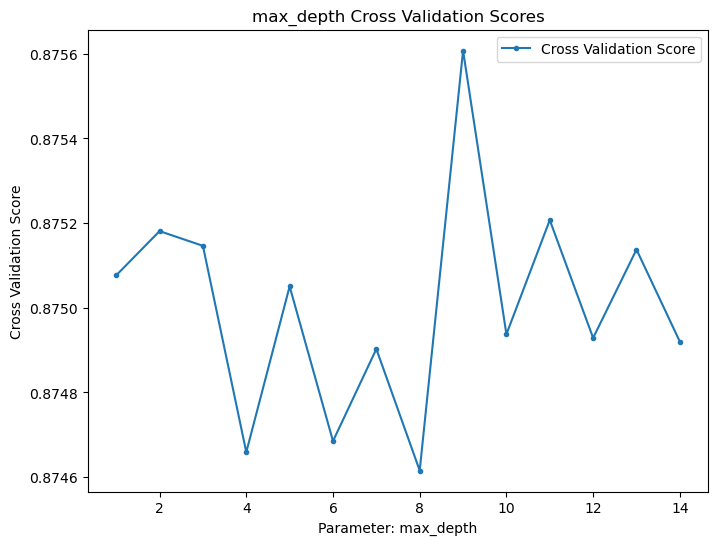

The best model has max_depth =  9


In [204]:
# Manually identify best max_depth for Random Forest

#Creating empty lists to keep track of scores
rf_cv_scores = []

# Create an array of max_depth
depth_range = np.array(range(1,15), dtype=int)

# Loop
for depth in depth_range:
    # Instantiate model
    rf_model = RandomForestClassifier(max_depth=depth)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest_sm, X_train_sm_ss, y_train_sm, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(depth_range, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: max_depth")
plt.ylabel("Cross Validation Score")
plt.title("max_depth Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal max_depth
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has max_depth = ", depth_range[index_of_max])

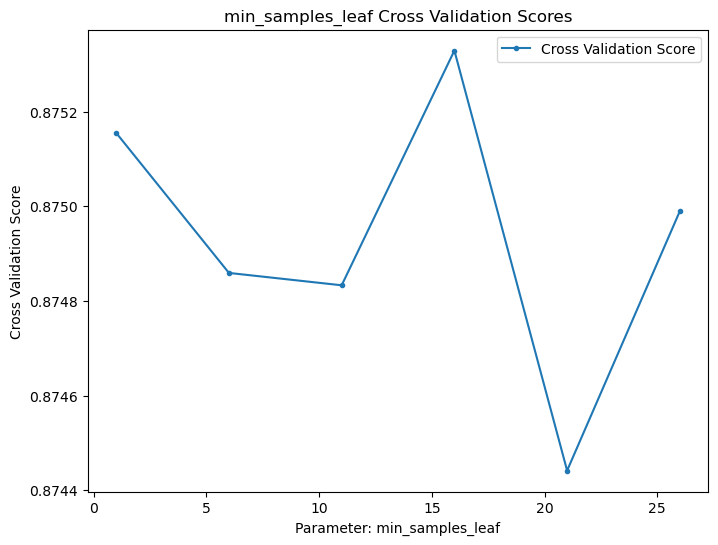

The best model has min_samples_leaf =  16


In [211]:
# Manually identify best min_samples_leaf for random forests

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of min_samples_leaf
min_samples = np.array(range(1,30,5), dtype=int)

# Loop
for leaf in min_samples:
    # Instantiate model
    rf_model = RandomForestClassifier(min_samples_leaf=leaf)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest_sm, X_train_sm_ss, y_train_sm, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(min_samples, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: min_samples_leaf")
plt.ylabel("Cross Validation Score")
plt.title("min_samples_leaf Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal min_samples_leaf
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has min_samples_leaf = ", min_samples[index_of_max])

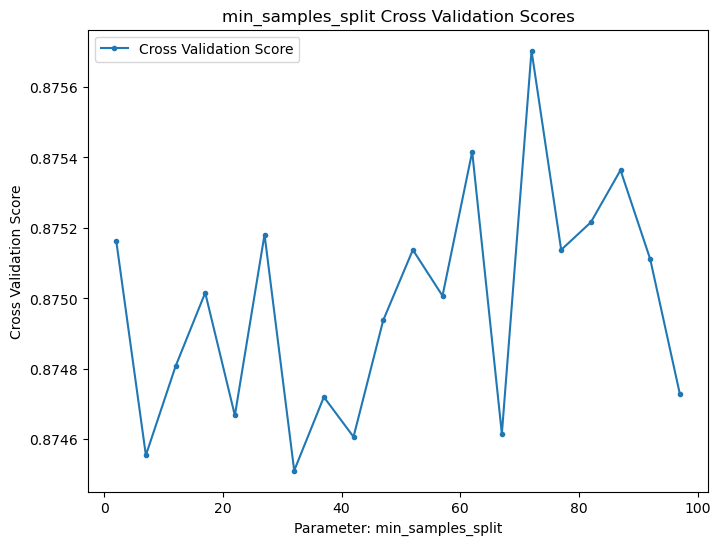

The best model has min_samples_split =  72


In [210]:
# Manually identify best min_samples_split

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of min_samples_split
min_splits = np.array(range(2,100,5), dtype=int)

# Loop
for split in min_splits:
    # Instantiate model
    rf_model = RandomForestClassifier(min_samples_split=split)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest_sm, X_train_sm_ss, y_train_sm, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(min_splits, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: min_samples_split")
plt.ylabel("Cross Validation Score")
plt.title("min_samples_split Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal min_samples_split
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has min_samples_split = ", min_splits[index_of_max])

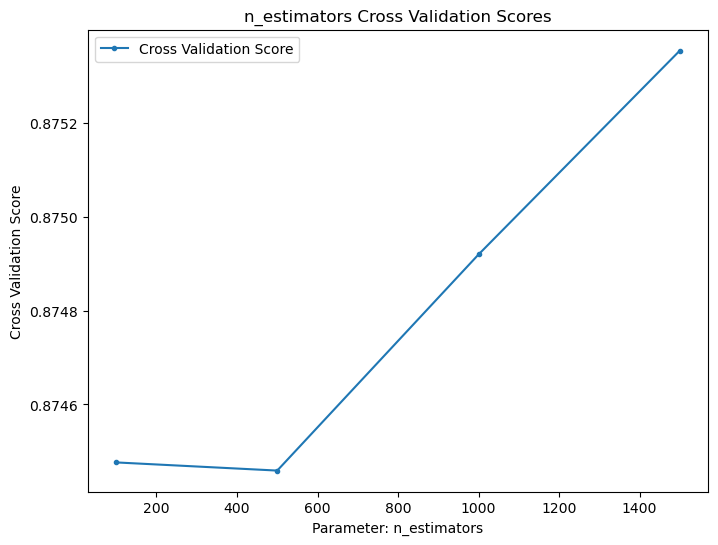

The best model has n_estimators =  1500


In [208]:
# Manually identify best n_estimators

#Creating empty lists to keep track of csores
rf_cv_scores = []

# Create an array of n_estimators
n_estimators = [100, 500, 1000, 1500]

# Loop
for n in n_estimators:
    # Instantiate model
    rf_model = RandomForestClassifier(n_estimators=n)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(random_forest_sm, X_train_sm_ss, y_train_sm, cv=5))

    # Score on TRAINING set
    rf_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(n_estimators, rf_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: n_estimators")
plt.ylabel("Cross Validation Score")
plt.title("n_estimators Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal C
index_of_max = np.array(rf_cv_scores).argmax()
print("The best model has n_estimators = ", n_estimators[index_of_max])

## <a id='toc10_1_'></a>[XGBoost Model: Manually identifying best hyperparameters ](#toc0_)

learning rate (eta) and number of trees (n_estimators)

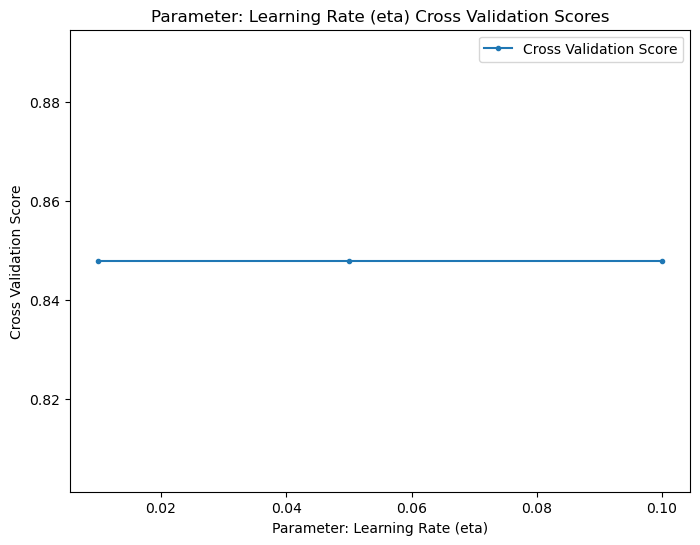

The best model has Learning Rate (eta) =  0.01


In [212]:
# Manually identify best max_depth for XGBoost

#Creating empty lists to keep track of scores
XGB_cv_scores = []

# Create an array of max_depth
eta_range = [0.01, 0.05, 0.1]

# Loop
for eta in eta_range:
    # Instantiate model
    rf_model = XGBClassifier(eta=eta)
   
    # Fit to TRAINING set
    cv_score = np.mean(cross_val_score(XGBoost_model_sm, X_train_sm_ss, y_train_sm, cv=5))

    # Score on TRAINING set
    XGB_cv_scores.append(cv_score)

#Plot cross validation result
plt.figure()
plt.plot(eta_range, XGB_cv_scores, label="Cross Validation Score", marker=".")

#plt.grid(alpha=0.1)
plt.xlabel("Parameter: Learning Rate (eta)")
plt.ylabel("Cross Validation Score")
plt.title("Parameter: Learning Rate (eta) Cross Validation Scores")
plt.legend()
plt.show()

# Print the optimal max_depth
index_of_max = np.array(XGB_cv_scores).argmax()
print("The best model has Learning Rate (eta) = ", eta_range[index_of_max])

# <a id='toc11_'></a>[WorkSpace](#toc0_)


In [ ]:
# # Scaling
# scaler = StandardScaler()

# # Fit and transform train
# X_train_scaled = scaler.fit_transform(X_train)

# # Only transforming the test
# X_test_scaled = scaler.transform(X_test)


## First Model Runs

## <a id='toc5_'></a>[Baseline Logistic Regression](#toc0_)

In [ ]:
# Instantiate the model
log_reg = LogisticRegression()

# Fit the model
log_reg.fit(X_train_scaled, y_train)

# Score the basemodel
print(f' Train score: {log_reg.score(X_train_scaled, y_train)}')

# Score on the test data
print(f' Test score: {log_reg.score(X_test_scaled, y_test)}')


 Train score: 0.783252895227097
 Test score: 0.7845999651385742


| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 79.98%      | 79.78%     | -                | -            | -        |


In [ ]:
# Get class predictions
y_pred = log_reg.predict(X_test_scaled)

In [ ]:
initial_report = classification_report(y_test, y_pred)
print(initial_report)

              precision    recall  f1-score   support

           0       0.77      0.93      0.84     14367
           1       0.82      0.54      0.65      8581

    accuracy                           0.78     22948
   macro avg       0.80      0.74      0.75     22948
weighted avg       0.79      0.78      0.77     22948



The baseline logistic regression model provided a test score of 95.42% accuracy.  I will perform a K-Fold Cross-Validation with max_iter=1000 to see if there is any changes to the accuracy.

### <a id='toc5_1_'></a>[K-Fold Cross-Validation](#toc0_)

In [ ]:
# Instantiate the model
log_reg2 = LogisticRegression(max_iter=1000)

# Perform 5-fold cross-validation for train
scores = cross_val_score(log_reg2, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {np.mean(scores)}")

Cross-validation scores: 0.7997799344723331


| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 95.35%      | 95.21%     | -                | -            | -        |
| Log_Reg2   | 94.97%      | n/a        | -                | 5            | 1000     |


The cross validation score of my model only decreased slightly to 94.97%. With a train and test score ~95%, next I'll check a confusion matrix and look into other evaluations like f-1 score, precision, and recall.

### <a id='toc5_2_'></a>[Confusion Matrix for Logistic Regression](#toc0_)
Using the baseline log_reg for confusion matrix:

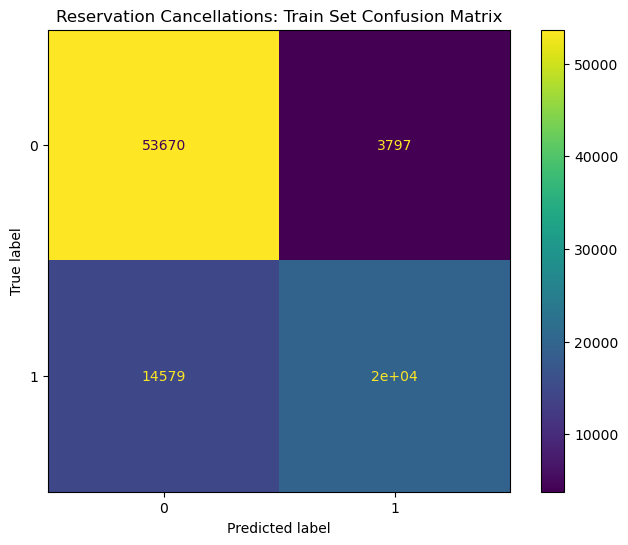

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_train_scaled, y_train)

plt.title('Reservation Cancellations: Train Set Confusion Matrix')

plt.show()

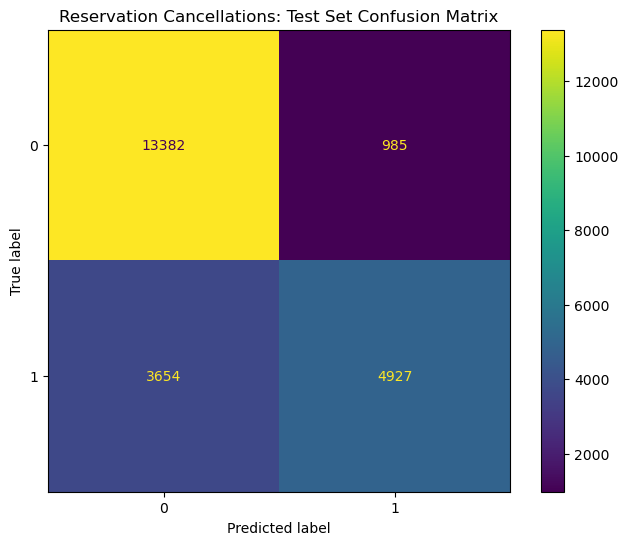

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test)

plt.title('Reservation Cancellations: Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 14,000 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: only 25 of the reservations that were predicted to cancel, actually did not cancel
- **False Negatives**: ~1000 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: 7500 of the total number of cancelled reservations were correctly identified by the model.

In [ ]:
# Get class predictions
y_pred = log_reg.predict(X_test_scaled)

In [ ]:
# Run classification Report
logreg_report = classification_report(y_test, y_pred)
print(logreg_report)

              precision    recall  f1-score   support

           0       0.79      0.93      0.85     14367
           1       0.83      0.57      0.68      8581

    accuracy                           0.80     22948
   macro avg       0.81      0.75      0.77     22948
weighted avg       0.80      0.80      0.79     22948



| Model      | Train Score | Test Score | Precision | Recall | f1-score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|-----------|--------|----------|------------------|--------------|----------|
| Log_Reg    | 79.98%      | 79.78%     |  83%      | 57%    | 68%      | -                | -            | -        |


The logistic regression model returned a f1 score of 93%. 

**Precision**: Out of all the reservations that the model predicted to to cancel, 100% actually canceled.

**Recall**: Out of all the reservations that cancelled, the model was able to predict 87% of them.


### Evaluate Coefficients

In [ ]:
# Checking coefficients values
pd.DataFrame({'coeff': log_reg.coef_[0]}, index=X_train.columns).sort_values('coeff')

,coeff
arrival_date_week_number,-1.178846
deposit_type_No Deposit,-0.991019
total_of_special_requests,-0.568943
status_month,-0.446174
status_dow,-0.410050
market_segment_Offline TA/TO,-0.323094
booking_changes,-0.287249
company,-0.262366
stays_in_weekend_nights,-0.234279
distribution_channel_Direct,-0.108941


Before exploring any additional tuning for logistic regression, I want to explore other models to see if their baseline performances are any better than the logistic regression model.

In [ ]:
extracted_df = final_df.copy()

In [ ]:
# Extract year, month, day of month from arrival_date for X_train
extracted_df['arrival_year'] = extracted_df['arrival_date'].dt.year
extracted_df['arrival_month'] = extracted_df['arrival_date'].dt.month
extracted_df['arrival_dow'] = extracted_df['arrival_date'].dt.weekday
extracted_df['arrival_day'] = extracted_df['arrival_date'].dt.day

# Extract year, month, day of month from reservation_status_date for X_train
extracted_df['status_year'] = extracted_df['reservation_status_date'].dt.year
extracted_df['status_month'] = extracted_df['reservation_status_date'].dt.month
extracted_df['status_dow'] = extracted_df['reservation_status_date'].dt.weekday
extracted_df['status_day'] = extracted_df['reservation_status_date'].dt.day


In [ ]:
# Drop original datetime columns for X_train
extracted_df.drop(columns='reservation_status_date', inplace=True)
extracted_df.drop(columns='arrival_date',inplace=True)


In [ ]:
extracted_df.head(2)

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,total_of_special_requests,day_demand,los,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,arrival_year,arrival_month,arrival_dow,arrival_day,status_year,status_month,status_dow,status_day
0,0,342,27,0,0,2,0,0,1,0,0,3,0,0,0,0.0,0,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,2015,7,2,1,2015,7,2,1
1,0,737,27,0,0,2,0,0,1,0,0,4,0,0,0,0.0,0,122,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,2015,7,2,1,2015,7,2,1


In [ ]:
#Explore status_year  - if i find anything, insert this into EDA and make comments on why it's inserted up here
status_year_df = extracted_df.groupby(['status_year', 'is_canceled'], dropna=False).size().unstack()
status_month_df = extracted_df.groupby(['status_month', 'is_canceled'], dropna=False).size().unstack()

status_year_df


is_canceled,0,1
status_year,,
2014,NaN,181.0
2015,11736.0,10308.0
2016,35554.0,21344.0
2017,24544.0,11070.0


In [ ]:
status_month_df

is_canceled,0,1
status_month,,
1,4538,5319
2,5066,4326
3,6328,3794
4,6374,3449
5,6900,3119
6,6079,2889
7,7411,4348
8,8109,2610
9,6093,2565


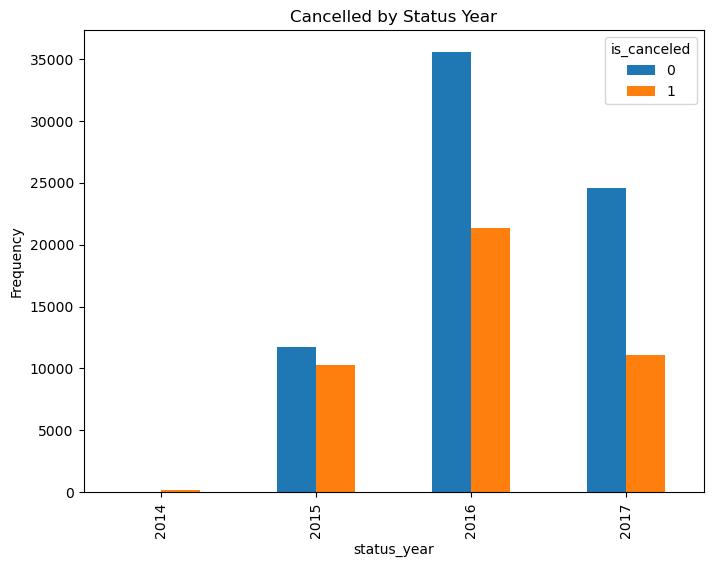

In [ ]:
# Plot Cancelled by status year
status_year_df.plot(kind='bar')
plt.title('Cancelled by Status Year')
plt.ylabel('Frequency')
plt.show()

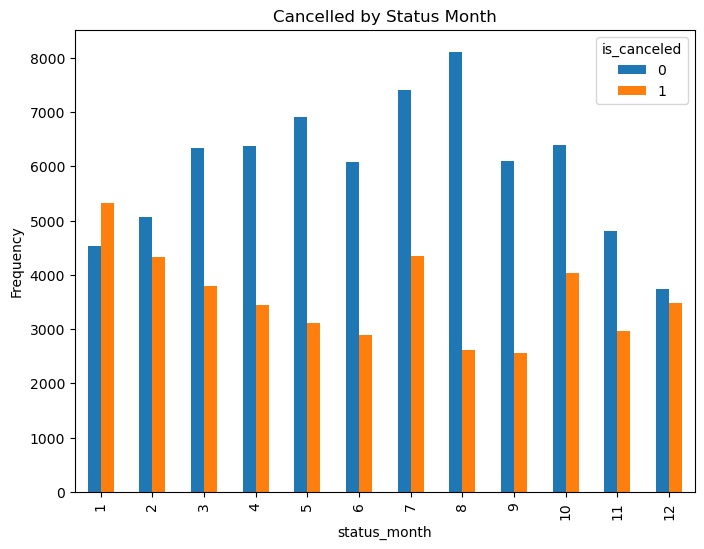

In [ ]:
# Plot Cancelled by status month
status_month_df.plot(kind='bar')
plt.title('Cancelled by Status Month')
plt.ylabel('Frequency')
plt.show()

## <a id='toc6_'></a>[Baseline Random Forest Model](#toc0_)

In [ ]:
# Instantiate random forest
random_forest = RandomForestClassifier(n_estimators=100) # instantiating and picking to train 100 DT models which is the default

# Fit the random forest model
random_forest.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest.score(X_test_scaled, y_test).round(3)}

      """)

 
Train Score: 0.99

Test Score: 0.853

      


| Model           | Train Score | Test Score | n_estimators | max_depth | n_samples_sp |
|------------------|-------------|------------|--------------|-----------|--------------|
| random_forest    | 100%        | 96.10%     | 1000         | -         | -            |


### <a id='toc6_1_'></a>[Grid Search for Random Forest Hyperparameters](#toc0_)


Based on manual hyperparameter optimization (see appendix), I will run a grid search on the optimal hyperparameters.


In [ ]:
#Creating pipeline for grid search
rf_estimators = [('random_forest', RandomForestClassifier())]
rf_pipe = Pipeline(rf_estimators)

#hyperparameters to search
rf_params = {'random_forest__n_estimators': [100, 800, 1000, 1500],
             'random_forest__max_depth': [3, 5, 7, 12],
             'random_forest__min_samples_split': [120, 220, 300, 302],
             'random_forest__min_samples_leaf': [1, 21, 25, 26]}

#rf_grid_search = GridSearchCV(rf_pipe, param_grid=rf_params)

#rf_fitted_search = rf_grid_search.fit(X_train_scaled, y_train)

#### <a id='toc6_1_1_'></a>[Save and Reload grid search results](#toc0_)

Saving and reloading grid search results because it took almost 800 minutes to complete.

In [ ]:
# Save grid search results
#joblib.dump(rf_fitted_search, 'rf_fitted_search.pkl')

# reload grid search results
rf_fitted_search = joblib.load('../data/rf_fitted_search.pkl')


In [ ]:
print("Best Random Forest Parameters:", rf_fitted_search.best_params_)
print("Best Cross-Validation Accuracy:", rf_fitted_search.best_score_)

Best Random Forest Parameters: {'random_forest__max_depth': 12, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 120, 'random_forest__n_estimators': 1500}
Best Cross-Validation Accuracy: 0.8701260494259715


Grid Search Results for Best Hyperparameters for Random Forest:
- max_depth: 12
- min_samples leaf: 1
- min_samples split: 120
- n_estimators: 1500

### <a id='toc6_2_'></a>[Random Forest Model with Grid Searched HyperParameters](#toc0_)

In [ ]:
# Instantiate random forest
random_forest2 = RandomForestClassifier(n_estimators=1500, 
                                        max_depth=12, 
                                        min_samples_split=120, 
                                        min_samples_leaf=1,
                                        random_state=24) 

# Fit the random forest model
random_forest2.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest2.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest2.score(X_test_scaled, y_test).round(3)}
      """)

 
Train Score: 0.877

Test Score: 0.869
      


| Model           | Train Score | Test Score | n_estimators | max_depth | min_samples_split | min_samples_leaf |
|-----------------|-------------|------------|--------------|-----------|-------------------|---------------|
| random_forest   | 100%        | 96.20%     | 1000         | -         | -                 | -             |
| random_forest2  | 87.40%      | 86.70%     | 1500         | 12        | 120               | 1             |




The random forest model with the hyperparameters from the grid search are a lot more promising and are not overfitted.  I will take the random_forest2 model to evaluate the model further

### <a id='toc6_3_'></a>[Confusion Matrix for Random Forest](#toc0_)

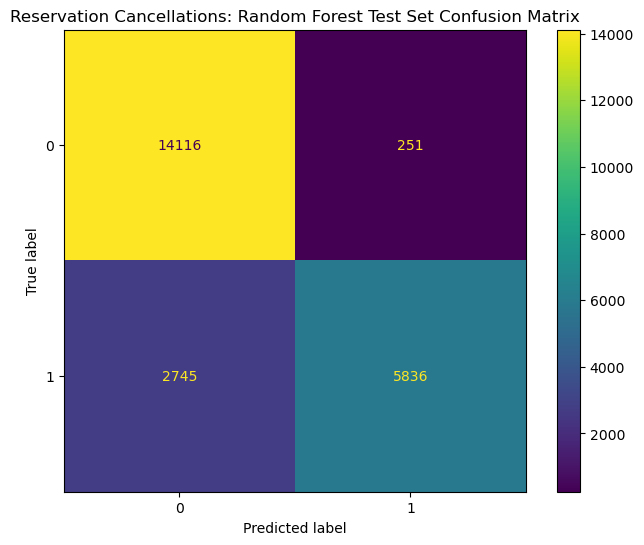

In [ ]:
# Instantiate Confusion Matrix
ConfusionMatrixDisplay.from_estimator(random_forest2, X_test_scaled, y_test)

plt.title('Reservation Cancellations: Random Forest Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 14,000 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: only ~300 of the reservations that the model predicted to cancel, did not cancel
- **False Negatives**: 2700 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: 5800 of the cancelled reservations were correctly predicted out of the 8500 total cancellations

In [ ]:
# Get class predictions for random_forest2
y_pred_rf = random_forest2.predict(X_test_scaled)

rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.84      0.98      0.90     14367
           1       0.96      0.68      0.80      8581

    accuracy                           0.87     22948
   macro avg       0.90      0.83      0.85     22948
weighted avg       0.88      0.87      0.86     22948



| Model           | Train Score | Test Score | Precision | Recall | f1-score | n_estimators | max_depth | min_samples_split | n_samples_leaf | class_weight |
|-----------------|-------------|------------|-----------|--------|----------|--------------|-----------|-------------------|----------------|--------------|
| random_forest   | 100%        | 96.20%     | -         | -      | -        | 1000         | -         | -                 | -              | -            |
| random_forest2  | 87.40%      | 86.70%     | 95%       | 68%    | 79%      | 1500         | 12        | 120               | 1              | -            |



The f1-score of the random_forest2 model is 79%, with a Precision of 95% but a lower recall of only 68%. Meaning out of all the cancellated reservations, the model was only able to predict 68% of them. 

I want to see if we can increase recall by adding the hyperparameter class_weight to evaluate changes to recall. I will run random_forest3 next with the additional hyperparameter class_weight:


In [ ]:
# Instantiate random forest3 with class_weight being balanced
random_forest3 = RandomForestClassifier(n_estimators=1500, 
                                        max_depth=12, 
                                        min_samples_split=120, 
                                        min_samples_leaf=1,
                                        random_state=24,
                                        class_weight='balanced') 
# Fit the random forest model
random_forest3.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {random_forest3.score(X_train_scaled, y_train).round(3)}

Test Score: {random_forest3.score(X_test_scaled, y_test).round(3)}""")

 
Train Score: 0.891

Test Score: 0.883


The train and test scores have increased slightly. Let's look at the classification report next:

In [ ]:
# Get class predictions
y_pred_rf3 = random_forest3.predict(X_test_scaled)

rf3_report = classification_report(y_test, y_pred_rf3)
print(rf3_report)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91     14367
           1       0.88      0.80      0.84      8581

    accuracy                           0.88     22948
   macro avg       0.88      0.87      0.87     22948
weighted avg       0.88      0.88      0.88     22948



| Model           | Train Score | Test Score | Precision | Recall | f1-score | n_estimators | max_depth | min_samples_split | min_sample_le | class_weight |
|-----------------|-------------|------------|-----------|--------|----------|--------------|-----------|-------------------|---------------|--------------|
| random_forest   | 100%        | 96.20%     | -         | -      | -        | 1000         | -         | -                 | -             | -            |
| random_forest2  | 87.40%      | 86.70%     | 95%       | 68%    | 79%      | 1500         | 12        | 120               | 1             | -            |
| random_forest3  | 88.90%      | 88.30%     | 88%       | 79%    | 84%      | 1500         | 12        | 120               | 1             | balanced     |



With random_forest3 by adding class weight to the random forest model, I increased accuracy slightly (1.4%) while decreasing overfitting (0.1%).  This also increased **Recall** by 11%, but decreased **Precision** by 7%, however this provided an overall **f1-score** of 84% (increase of 5%).

## <a id='toc7_'></a>[Model Comparison](#toc0_)

Before looking at further model evaluation, here is a summary table of the models run so far:


| Model           | Train Score | Test Score | Precision | Recall | f1-score | Hyperparameter C | K-Fold Cross | Max_Iter |
|-----------------|-------------|------------|-----------|--------|----------|------------------|--------------|----------|
| Log_Reg         | 95.50%      | 95.42%     | 100%      | 87%    | 93%      | -                | -            | -        |



| Model           | Train Score | Test Score | Precision | Recall | f1-score | n_estimators | max_depth | min_samples_split | min_sample_le | class_weight |
|-----------------|-------------|------------|-----------|--------|----------|--------------|-----------|-------------------|---------------|--------------|
| random_forest   | 100%        | 96.20%     | -         | -      | -        | 1000         | -         | -                 | -             | -            |
| random_forest2  | 87.40%      | 86.70%     | 95%       | 68%    | 79%      | 1500         | 12        | 120               | 1             | -            |
| random_forest3  | 88.90%      | 88.30%     | 88%       | 79%    | 84%      | 1500         | 12        | 120               | 1             | balanced     |



Based on the models, for my next steps I will evaluate the log_reg and random_forest3 models further
1. ROC and AUC for log_reg
2. ROC and AUC for random_forest3

### <a id='toc7_1_'></a>[Model Evaluation of log_reg](#toc0_)

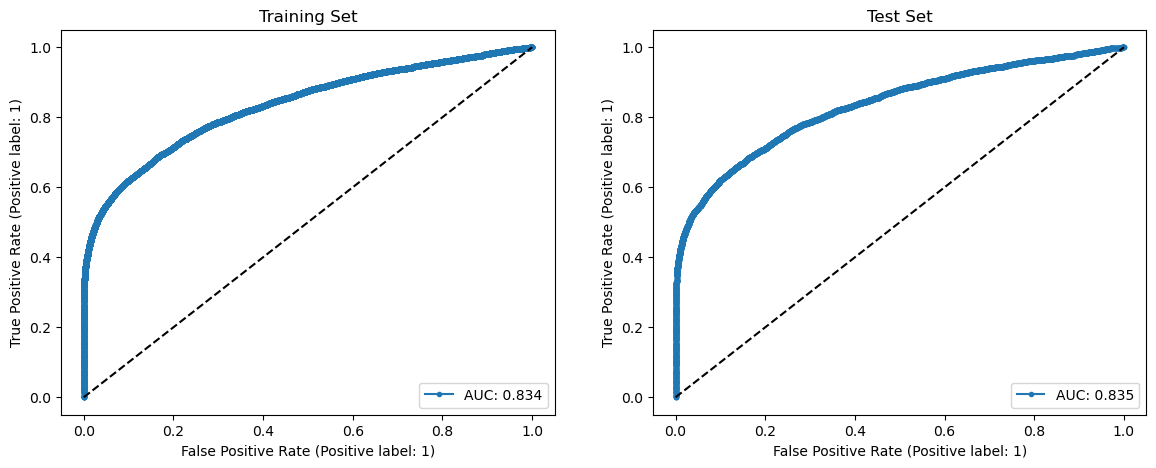

Training Set AUC: 0.834
Test Set AUC: 0.835


In [ ]:
#Predict probabilities
y_proba_train = log_reg.predict_proba(X_train_scaled)[:,1]
y_proba_test = log_reg.predict_proba(X_test_scaled)[:,1]

# Score (AUC)
logreg_auc_train = np.round(roc_auc_score(y_train, y_proba_train),3)
logreg_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {logreg_auc_train}"
test_label = f"AUC: {logreg_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(log_reg, X_train_scaled, y_train, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(log_reg, X_test_scaled, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("Training Set")
axes[1].set_title("Test Set")


plt.show()

print(f"Training Set AUC: {logreg_auc_train}")
print(f"Test Set AUC: {logreg_auc_test}")

The area under the curve (AUC) for the log_reg model is 99.2% with very minimal overfitting as both the training and test set are a different of 0.1%.

### <a id='toc7_2_'></a>[Model Evaluation of random_forest3](#toc0_)

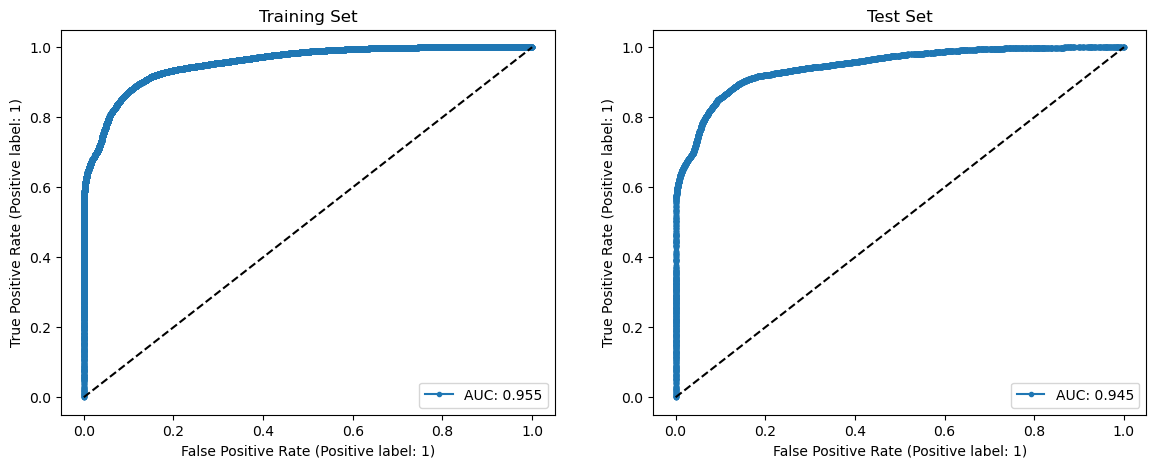

Training Set AUC: 0.955
Test Set AUC: 0.945


In [ ]:
#Predict probabilities
y_proba_train = random_forest3.predict_proba(X_train_scaled)[:,1]
y_proba_test = random_forest3.predict_proba(X_test_scaled)[:,1]

# Score (AUC)
random_forest3_auc_train = np.round(roc_auc_score(y_train, y_proba_train),3)
random_forest3_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {random_forest3_auc_train}"
test_label = f"AUC: {random_forest3_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(random_forest3, X_train_scaled, y_train, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(random_forest3, X_test_scaled, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("Training Set")
axes[1].set_title("Test Set")
plt.show()

print(f"Training Set AUC: {random_forest3_auc_train}")
print(f"Test Set AUC: {random_forest3_auc_test}")

The area under the curve (AUC) for the random_forest3 model is 94.7% with  minimal overfitting as both the training and test set are a different of 0.7%.

Comparing the models overall scores:

| Model          | Train AUC | Test AUC | Train Score | Test Score | Precision | Recall | f1-score |
|----------------|-----------|----------|-------------|------------|-----------|--------|----------|
| Log_Reg        | 99.30%    | 99.20%   | 95.50%      | 95.42%     | 100%      | 87%    | 93%      |
| random_forest3 | 95.40%    | 94.70%   | 88.90%      | 88.30%     | 88%       | 79%    | 84%      |


To my surprise, the baseline logistic regression model the best overall performance between the two models. However, there is one metric I am a little suspicious about and that is precision.  I know it is due to rounding, but a near 100% precision is something I want to look into further.

## <a id='toc8_'></a>[Feature Importance](#toc0_)
Identify feature importance between the log_reg and random_forest3 models

### <a id='toc8_1_'></a>[Random Forest Feature Importance:](#toc0_)

In [ ]:
%%time

# Determine random forest feature importance using the test set
# Repeat the permuation step 5 times per column.
rf_result = permutation_importance(random_forest3, X_test_scaled, y_test, n_repeats=5, random_state=0)

CPU times: user 6min 36s, sys: 1.69 s, total: 6min 38s
Wall time: 6min 42s


In [ ]:
# Calculate the average importance per feature for Random Forest Model
importances = rf_result.importances_mean

# Normalize the importances
normalized_importances = importances / importances.sum()


# Put the variable names and their feature importances into a data frame
rf_permute_importances_df = pd.DataFrame({'Variable': X_train.columns,
                               'Importance': importances,
                               'Normalized Importance': normalized_importances})

rf_permute_importances_df.sort_values(by='Importance', ascending=False, inplace=True, ignore_index=True)

rf_permute_importances_df

,Variable,Importance,Normalized Importance
0,total_of_special_requests,0.063256,0.160625
1,status_month,0.049800,0.126455
2,status_dow,0.049608,0.125968
3,deposit_type_Non Refund,0.032683,0.082990
4,lead_time,0.030103,0.076440
5,stays_in_weekend_nights,0.027549,0.069955
6,previous_cancellations,0.020978,0.053269
7,deposit_type_No Deposit,0.016184,0.041097
8,required_car_parking_spaces,0.011896,0.030208
9,market_segment_Online TA,0.011443,0.029058


### <a id='toc8_2_'></a>[Logistic Regression Feature Importance:](#toc0_)

In [ ]:
%%time

# Determine logistic regression feature importance using the test set
# Repeat the permuation step 5 times per column.
log_reg_result = permutation_importance(log_reg, X_test_scaled, y_test, n_repeats=5, random_state=0)

CPU times: user 4.39 s, sys: 1.34 s, total: 5.74 s
Wall time: 851 ms


In [ ]:
# Calculate the average importance per feature for Logistic Regression Model
importances = log_reg_result.importances_mean

# Normalize the importances
normalized_importances = importances / importances.sum()


# Put the variable names and their feature importances into a data frame
logreg_permute_importances_df = pd.DataFrame({'Variable': X_train.columns,
                               'Importance': importances,
                               'Normalized Importance': normalized_importances})

logreg_permute_importances_df.sort_values(by='Importance', ascending=False, inplace=True, ignore_index=True)

logreg_permute_importances_df

,Variable,Importance,Normalized Importance
0,status_month,0.356894,0.229989
1,arrival_month,0.329501,0.212337
2,status_year,0.309352,0.199352
3,arrival_year,0.279379,0.180037
4,status_day,0.111766,0.072024
5,arrival_day,0.104663,0.067447
6,arrival_date_week_number,0.044623,0.028756
7,required_car_parking_spaces,0.017814,0.011480
8,lead_time,0.001612,0.001039
9,previous_cancellations,0.001220,0.000786


Plotting both model importances:

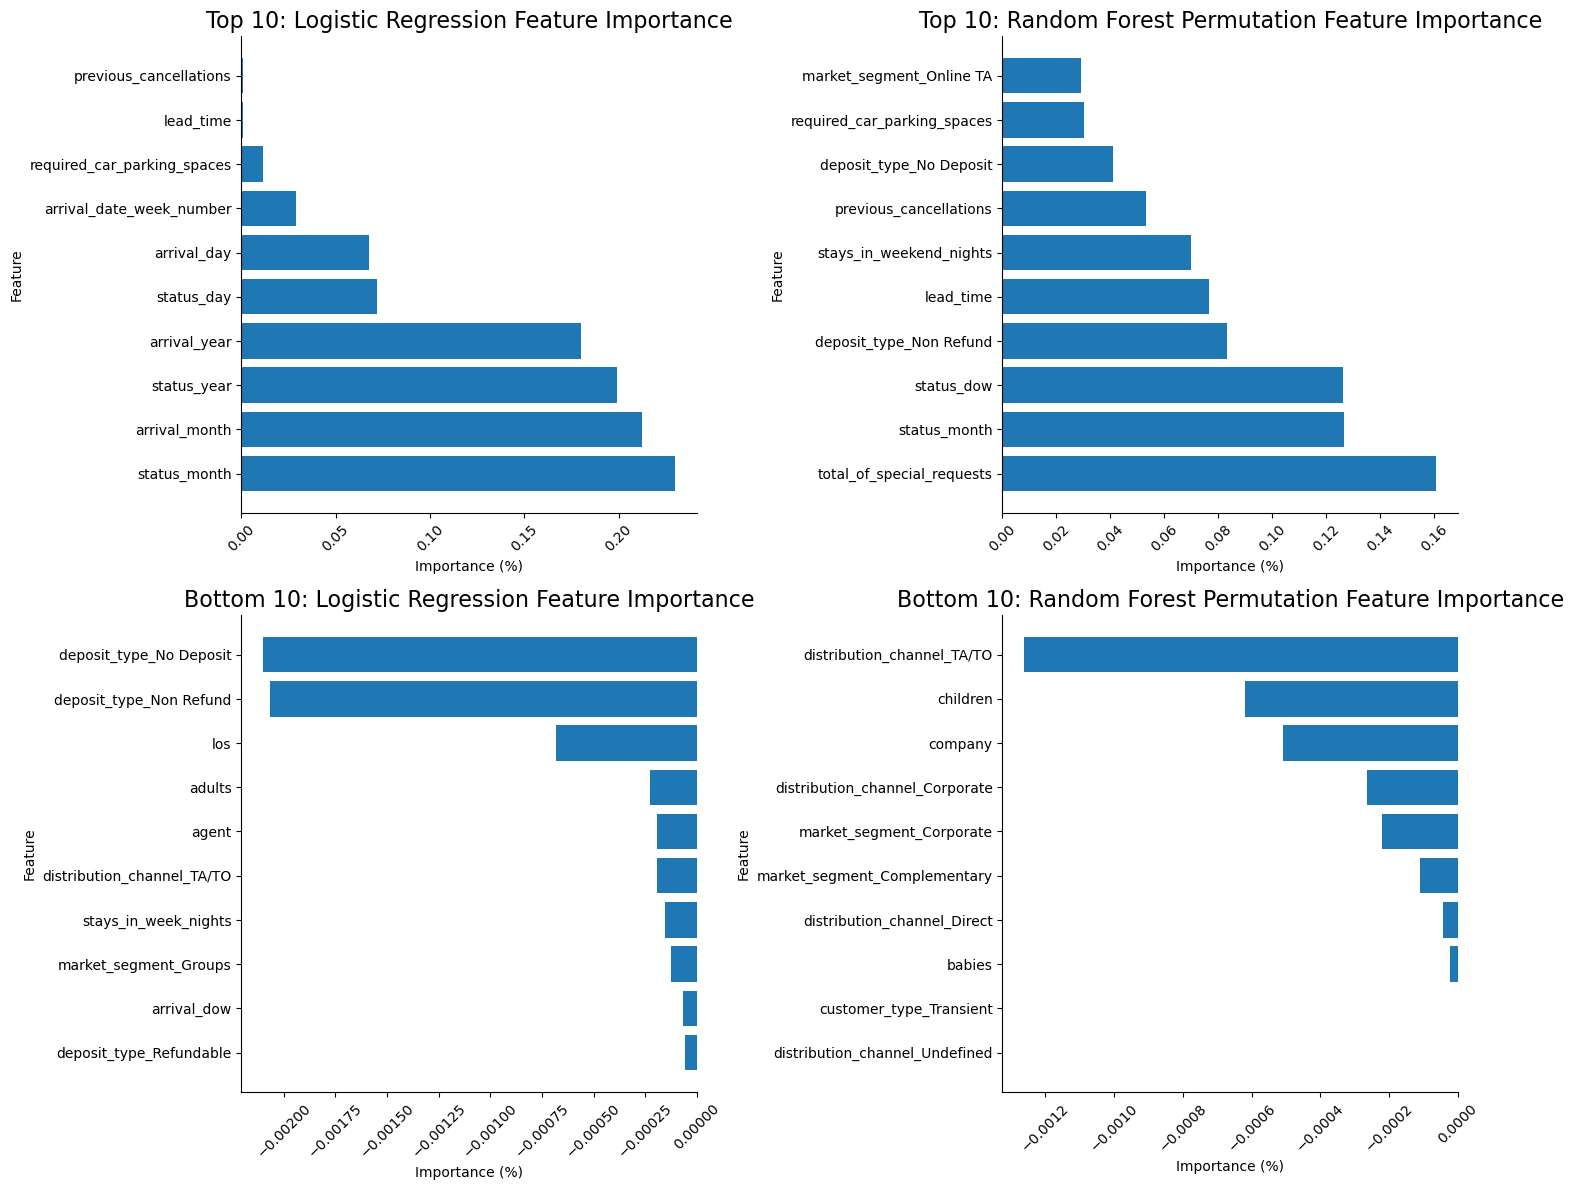

In [ ]:
# Plot the importances

plt.subplots(2, 2, figsize=(15,12))

plt.subplot(2, 2, 1) # Top 10: Logistic Regression Permutation Feature Importance
plt.barh(logreg_permute_importances_df['Variable'].head(10), logreg_permute_importances_df['Normalized Importance'].head(10))
plt.title('Top 10: Logistic Regression Feature Importance', fontsize=16)
plt.ylabel('Feature')
plt.xlabel('Importance (%)')
plt.xticks(rotation = 45)
sns.despine()

plt.subplot(2, 2, 2) # Top 10: Random Forest Permutation Feature Importance
plt.barh(rf_permute_importances_df['Variable'].head(10), rf_permute_importances_df['Normalized Importance'].head(10))
plt.title('Top 10: Random Forest Permutation Feature Importance', fontsize=16)
plt.ylabel('Feature')
plt.xlabel('Importance (%)')
plt.xticks(rotation = 45)
sns.despine()

plt.subplot(2, 2, 3) # Bottom 10: Logistic Regression Permutation Feature Importance
plt.barh(logreg_permute_importances_df['Variable'].tail(10), logreg_permute_importances_df['Normalized Importance'].tail(10))
plt.title('Bottom 10: Logistic Regression Feature Importance', fontsize=16)
plt.ylabel('Feature')
plt.xlabel('Importance (%)')
plt.xticks(rotation = 45)
sns.despine()

plt.subplot(2, 2, 4) # Bottom 10: Random Forest Permutation Feature Importance
plt.barh(rf_permute_importances_df['Variable'].tail(10), rf_permute_importances_df['Normalized Importance'].tail(10))
plt.title('Bottom 10: Random Forest Permutation Feature Importance', fontsize=16)
plt.ylabel('Feature')
plt.xlabel('Importance (%)')
plt.xticks(rotation = 45)
sns.despine()


plt.tight_layout()
plt.show()

The feature importance plot above indicates features that are more influential in predicting our target variable, 'is_canceled'.

Logistic Regression top 3 most important features:
1. status_month
2. arrival_month
3. status_year

Random Forest top 3 more important features:
1. total_of_special_requests
2. status_month
3. status_dow

With the Random Forest model, with the highest feature `total_of_special_requests` just over 16% the sum of the first 5 importances is just over 57%, whereas the Logistic Regression model has a highest feature being 22% and the sum of the first 5 importances is over 89%. This means that the logistic regression model indicates that there are fewer features that have a heavier influence in predicting the target variable compared to the random forest model's feature importances are more spread out between more features.

Logistic Regression top 3 features with **negative** importance:
1. deposit_type_No Deposit
2. deposit_type_Non Refundable
3. los

Random Forest top 3 features with **negative** importance:
1. distribution_channel_TA/TO
2. children
3. company

Negative features in may be causing more harm in the model due to potential redundance or colinearity.
Deposit types and length of stay were the top negative importance features for the Logistic Regression model and the distribution channel of Travel Agent/Tour Operator from the Random Forest models surprise me as I have anticipated that these features could have stronger influence in predicting if a reservation would be cancelled or not.

## Baseline XGBoost Model

In [ ]:
# Instantiate XGBoost
XGBoost_model = XGBClassifier() 
XGBoost_model.fit(X_train_scaled, y_train)

# Score Train and Test
print(f""" 
Train Score: {XGBoost_model.score(X_train_scaled, y_train).round(3)}

Test Score: {XGBoost_model.score(X_test_scaled, y_test).round(3)}

""")

 
Train Score: 0.845

Test Score: 0.827




### XGBoost Evaluation

In [ ]:
y_pred_boost = XGBoost_model.predict(X_test_scaled)
print(f'Precision score: {precision_score(y_test,y_pred_boost)*100:0.2f}%')
print(f'Recall score: {recall_score(y_test,y_pred_boost)*100:0.2f}%')
print(f'F1 score: {f1_score(y_test,y_pred_boost)*100:0.2f}%')
print(classification_report(y_test, y_pred_boost))

Precision score: 99.87%
Recall score: 99.71%
F1 score: 99.79%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14367
           1       1.00      1.00      1.00      8581

    accuracy                           1.00     22948
   macro avg       1.00      1.00      1.00     22948
weighted avg       1.00      1.00      1.00     22948



| Model                    | Train Score | Test Score | Precision | Recall  | f1-score |
|--------------------------|-------------|------------|-----------|---------|----------|
| XGBoost_model            | 100%        | 99.80%     | 99.87%    | 99.71%  | 99.79%   |


The XGBoost baseline model is also demonstrating a 100% accuracy, precision, recall, and f1-scores. Before I proceed further with any hyperparameter turning, I would like to explore balancing the data to see if balancing is the issue with the high result metrics.

## <a id='toc11_1_'></a>[GridSearch for Logistic Regression](#toc0_)

In [245]:
# #Creating pipeline for grid search
# estimators = [('logreg', LogisticRegression())]
# pipe = Pipeline(estimators)

# #hyperparameters to search
# params = {'logreg__C': [0.001, 0.1, 1, 100, 1000],
#           'logreg__max_iter': [100, 200, 500, 1000]}

# grid_search = GridSearchCV(pipe, param_grid=params)

# fitted_search = grid_search.fit(X_train_scaled, y_train)

In [246]:
# print("Best Parameters:", grid_search.best_params_)
# print("Best Cross-Validation Accuracy:", grid_search.best_score_)

## <a id='toc11_2_'></a>[Logistic Regression with optimized Hyperparameter C and max_iter](#toc0_)

In [247]:
# # Instantiate the model
# log_reg3 = LogisticRegression(C=1000, max_iter=500)

# # Fit the model
# log_reg3.fit(X_train_scaled, y_train)

# # Score the basemodel
# print(f' Train score: {log_reg3.score(X_train_scaled, y_train)}')

# # Score on the test data
# print(f' Test score: {log_reg3.score(X_test_scaled, y_test)}')

The results look to be overfitted with such a high C value.

| Model      | Train Score | Test Score | Hyperparameter C | K-Fold Cross | Max_Iter |
|------------|-------------|------------|------------------|--------------|----------|
| Log_Reg    | 95.50%      | 95.42%     | -                | -            | -        |
| Log_Reg2   | 94.99%      | n/a        | -                | 5            | 1000     |
| Log_Reg3   | 99.48%      | 99.45%     | C = 1000         | -            | 500      |


## <a id='toc11_3_'></a>[Hyperparameter optimization for C](#toc0_)

In [248]:
# #Use Cross Validation to find the best C value

# # Store the results
# cross_validation_scores = []

# # Create an array of powers of ten for the values of inverse regularization strength C
# C_range = 10 ** np.array(range(-5, 5), dtype=float)

# # Perform cross validation
# for C in C_range:
#     model = LogisticRegression(C=C, random_state=24, max_iter=1000)

#     # The cross validation score (mean of scores from all folds)
#     cv_score = np.mean(cross_val_score(model, X_train_scaled, y_train, cv=5))

#     # Append the score
#     cross_validation_scores.append(cv_score)

# plt.figure(figsize=(5,3))
# plt.plot(C_range, cross_validation_scores, label="Cross Validation Score", marker=".")
# plt.xscale("log")
# plt.grid(alpha=0.1)
# plt.xlabel("Regularization Parameter: C")
# plt.ylabel("Cross Validation Score")
# plt.title("Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal C
# index_of_max = np.array(cross_validation_scores).argmax()
# print("The best model has C = ", C_range[index_of_max])

Based on the the plot above using cross validation to obtain an optimal C hyperparameter, 10000 will be what I attempt to use next

## <a id='toc11_4_'></a>[PCA with Log_Reg model](#toc0_)
- Attempting PCA with the same hyperparameters as log_reg2 model with max iter of 1000 to see if model scores improve

In [249]:
# # Create the PCA object
# PCA_object = PCA()

# # Fit the PCA object to the data
# PCA_object.fit(X_train_scaled)

# # Transform the original data
# X_PCA_train = PCA_object.transform(X_train_scaled)
# X_PCA_test = PCA_object.transform(X_test_scaled)

In [250]:
## Instantiate
# log_reg4 = LogisticRegression(max_iter=1000)

# # Fit logreg model to X_train
# log_reg4.fit(X_PCA_train, y_train)

# # Scoring the logreg model
# print(f' Train score: {log_reg4.score(X_PCA_train, y_train)}')
# print(f' Test score: {log_reg4.score(X_PCA_test, y_test)}')

After applying PCA, the accuracies between train and test have dropped to ~99%

## Manually identifying best hyperparameters for Random Forest Model (UNBALANCED)

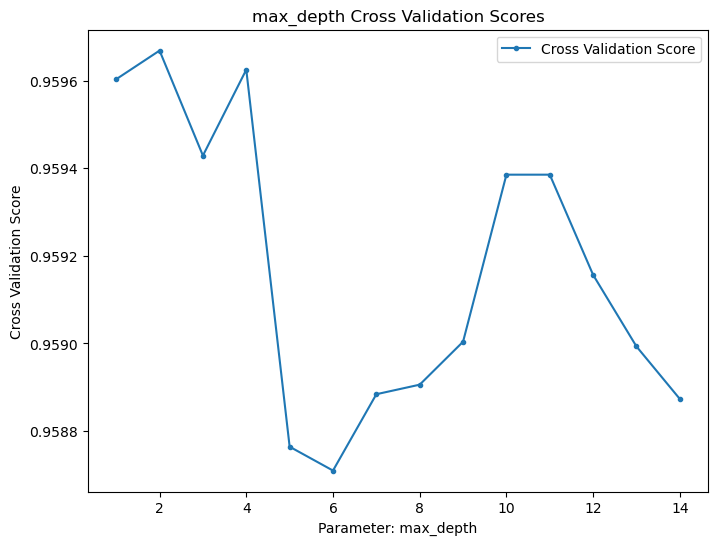

The best model has max_depth =  2


In [ ]:
# # Manually identify best max_depth for Random Forest

# #Creating empty lists to keep track of scores
# rf_cv_scores = []

# # Create an array of max_depth
# depth_range = np.array(range(1,15), dtype=int)

# # Loop
# for depth in depth_range:
#     # Instantiate model
#     rf_model = RandomForestClassifier(max_depth=depth)
   
#     # Fit to TRAINING set
#     cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

#     # Score on TRAINING set
#     rf_cv_scores.append(cv_score)

# #Plot cross validation result
# plt.figure()
# plt.plot(depth_range, rf_cv_scores, label="Cross Validation Score", marker=".")

# #plt.grid(alpha=0.1)
# plt.xlabel("Parameter: max_depth")
# plt.ylabel("Cross Validation Score")
# plt.title("max_depth Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal max_depth
# index_of_max = np.array(rf_cv_scores).argmax()
# print("The best model has max_depth = ", depth_range[index_of_max])

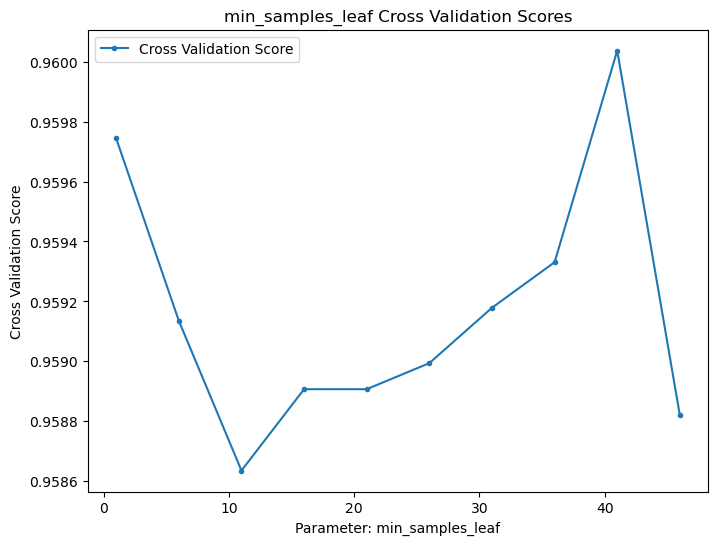

The best model has min_samples_leaf =  41


In [ ]:
# # Manually identify best min_samples_leaf for random forests

# #Creating empty lists to keep track of csores
# rf_cv_scores = []

# # Create an array of min_samples_leaf
# min_samples = np.array(range(1,50,5), dtype=int)

# # Loop
# for leaf in min_samples:
#     # Instantiate model
#     rf_model = RandomForestClassifier(min_samples_leaf=leaf)
   
#     # Fit to TRAINING set
#     cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

#     # Score on TRAINING set
#     rf_cv_scores.append(cv_score)

# #Plot cross validation result
# plt.figure()
# plt.plot(min_samples, rf_cv_scores, label="Cross Validation Score", marker=".")

# #plt.grid(alpha=0.1)
# plt.xlabel("Parameter: min_samples_leaf")
# plt.ylabel("Cross Validation Score")
# plt.title("min_samples_leaf Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal min_samples_leaf
# index_of_max = np.array(rf_cv_scores).argmax()
# print("The best model has min_samples_leaf = ", min_samples[index_of_max])

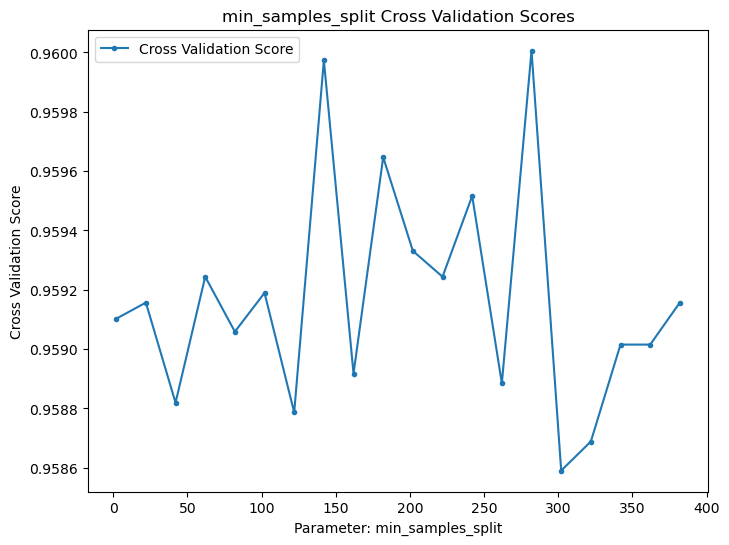

The best model has min_samples_split =  282


In [ ]:
# # Manually identify best min_samples_split

# #Creating empty lists to keep track of csores
# rf_cv_scores = []

# # Create an array of min_samples_split
# min_splits = np.array(range(2,400,20), dtype=int)

# # Loop
# for split in min_splits:
#     # Instantiate model
#     rf_model = RandomForestClassifier(min_samples_split=split)
   
#     # Fit to TRAINING set
#     cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

#     # Score on TRAINING set
#     rf_cv_scores.append(cv_score)

# #Plot cross validation result
# plt.figure()
# plt.plot(min_splits, rf_cv_scores, label="Cross Validation Score", marker=".")

# #plt.grid(alpha=0.1)
# plt.xlabel("Parameter: min_samples_split")
# plt.ylabel("Cross Validation Score")
# plt.title("min_samples_split Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal min_samples_split
# index_of_max = np.array(rf_cv_scores).argmax()
# print("The best model has min_samples_split = ", min_splits[index_of_max])

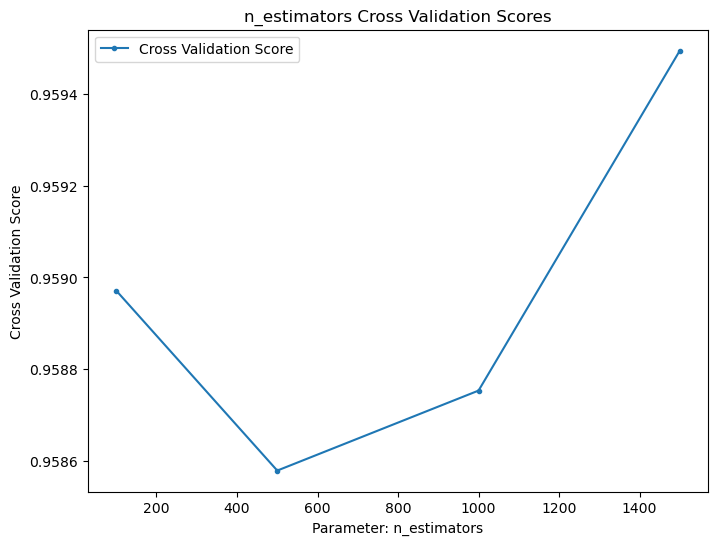

The best model has n_estimators =  1500


In [ ]:
# # Manually identify best n_estimators

# #Creating empty lists to keep track of csores
# rf_cv_scores = []

# # Create an array of n_estimators
# n_estimators = [100, 500, 1000, 1500]

# # Loop
# for n in n_estimators:
#     # Instantiate model
#     rf_model = RandomForestClassifier(n_estimators=n)
   
#     # Fit to TRAINING set
#     cv_score = np.mean(cross_val_score(random_forest, X_train_scaled, y_train, cv=5))

#     # Score on TRAINING set
#     rf_cv_scores.append(cv_score)

# #Plot cross validation result
# plt.figure()
# plt.plot(n_estimators, rf_cv_scores, label="Cross Validation Score", marker=".")

# #plt.grid(alpha=0.1)
# plt.xlabel("Parameter: n_estimators")
# plt.ylabel("Cross Validation Score")
# plt.title("n_estimators Cross Validation Scores")
# plt.legend()
# plt.show()

# # Print the optimal C
# index_of_max = np.array(rf_cv_scores).argmax()
# print("The best model has n_estimators = ", n_estimators[index_of_max])

## <a id='toc11_5_'></a>[Cancellation Days before arrival Feature engineering](#toc0_)
- How many days before arrival do cancellations occur? For `reservation_status` that are 'Canceled' how many days between `reservation_status_date` and `arrival_date`?

Additional EDA: 
- Cancellation window by `market_segment`


In [251]:
# Value counts of reservation status
#clean_df['reservation_status'].value_counts()

In [252]:
# Calculate the difference between the arrival_date and reservation_status_date  
#clean_df['date_diff'] = (clean_df['arrival_date'] - clean_df['reservation_status_date']).dt.days # converting the results into an integer

In [253]:
# Sanity check
#clean_df['date_diff'].head(5)

In [254]:
# pull data where reservation_status == Canceled
#canceled_res = clean_df[clean_df['reservation_status']=='Canceled']

In [255]:
#canceled_res['date_diff'].describe()

The average date difference between a cancellation being made and the arrival date of the reservation is 88 days. 

In [256]:
# Value counts of date_diff to see the top 10 date differences with cancelled reservations
#canceled_res['date_diff'].value_counts().head(10)

The largest number of cancellations occur on the same day of arrival (881 cancellations)

In [257]:
# Date diff by market segment
#canceled_res.groupby(['market_segment', 'date_diff']).size().unstack(fill_value=0)


Many of the cancellations that are further out (400+ days) are groups. While majority of the cancellations within 10 days are with Online Travel Agents.

## <a id='toc11_6_'></a>[Identify thresholds to maximize f1 score for random forests](#toc0_)

In [258]:
# # Identify thresholds to maximize f1

# # make probablistic predictions
# y_proba_rf = random_forest3.predict_proba(X_test)[:, 1]

# # Vary thresholds by 0.05 from 0.05 to 0.95
# thresholds = np.arange(0.05, 1, 0.05)

# precisions = list()
# recalls = list()

# for threshold in thresholds:
#     # Apply threshold
#     y_threshold = np.where(y_proba_rf > threshold, 1, 0)

#     # Calculate precision and recall
#     precision = precision_score(y_test, y_threshold)
#     recall = recall_score(y_test, y_threshold)

#     # Append to list
#     precisions.append(precision)
#     recalls.append(recall)

# # Visualize the result
# plt.figure()

# plt.plot(thresholds, precisions, label="precision", marker="o")
# plt.plot(thresholds, recalls, label="recall", marker="o")

# plt.xlim(0, 1)
# plt.xlabel("Threshold")
# plt.ylabel("Score")
# plt.title("Precision And Recall Trade-Off Across Varying Thresholds")
# plt.legend()

# plt.show()


## <a id='toc11_7_'></a>[ToDo: Transform the market segment and customer type features so that I can see a breakdown by date with the date as the index](#toc0_)

In [259]:
# # Plot the positive importances

# plt.subplots(1, 2, figsize=(15,8))

# plt.subplot(1, 2, 1) # Top 10: Logistic Regression Permutation Feature Importance
# plt.barh(logreg_permute_importances_df['Variable'].head(10), logreg_permute_importances_df['Normalized Importance'].head(10))
# plt.title('Top 10: Logistic Regression Feature Importance', fontsize=16)
# plt.ylabel('Feature')
# plt.xlabel('Importance (%)')
# plt.xticks(rotation = 45)
# sns.despine()

# plt.subplot(1, 2, 2) # Top 10: Random Forest Permutation Feature Importance
# plt.barh(rf_permute_importances_df['Variable'].head(10), rf_permute_importances_df['Normalized Importance'].head(10))
# plt.title('Top 10: Random Forest Permutation Feature Importance', fontsize=16)
# plt.ylabel('Feature')
# plt.xlabel('Importance (%)')
# plt.xticks(rotation = 45)
# sns.despine()


# plt.tight_layout()
# plt.show()